In [1]:
import numpy as np
import pandas as pd
import os

import scipy.stats.contingency as scp_cont
from scipy import stats
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
from itertools import combinations

import matplotlib.pyplot as plt
import seaborn as sns

import scorecardpy as sc


 # Spiegazione del rapporto di ogni variabile vs PM10

In [2]:
#lista di variabili selezionate

list_var = ['pressure_msl_max',
 'relative_humidity_2m_min',
 'precipitation_sum',
 'cloud_cover_mean',
 'dew_point_2m_max',
 'temperature_2m_max',
 'soil_moisture_28_to_100cm_mean',
 'soil_moisture_0_to_7cm_mean',
 'soil_temperature_0_to_7cm_mean',
 'wind_speed_10m_mean',
 'wind_speed_10m_min',
 'wind_gusts_10m_max',
 'wind_direction_10m_dominant',
 'shortwave_radiation_sum',
 'sunset_minutes',
 'et0_fao_evapotranspiration',
 'wind_gusts_10m_mean',
 'relative_humidity_2m_mean',
 'soil_temperature_0_to_100cm_mean',
 'cloud_cover_max',
 ]

list_var_new = ['precipitation_sum',
                    'cloud_cover_max',
                    'wind_speed_10m_min',
                    'wind_gusts_10m_max',
                    'pressure_msl_max',
                    'soil_moisture_28_to_100cm_mean',
                    'sunset_minutes',
                    'dew_point_2m_max',
                    'temperature_2m_max',
                    'shortwave_radiation_sum'
                     ]

## Preparazione del dataset

In [3]:
data_dir = os.path.join("..", "data")

df_SF = pd.read_parquet(os.path.join(data_dir, "df_SF.parquet"))
df_VC = pd.read_parquet(os.path.join(data_dir, "df_VC.parquet"))
df_GM = pd.read_parquet(os.path.join(data_dir, "df_GM.parquet"))
df_OP =  pd.read_parquet(os.path.join(data_dir, 'daily_df.parquet'))

In [4]:
df_SF['date'] = pd.to_datetime(df_SF['giorno'])
df_SF = df_SF.drop(columns=['giorno'])

df_GM['date'] = pd.to_datetime(df_GM['giorno'])
df_GM = df_GM.drop(columns=['giorno'])

df_VC['date'] = pd.to_datetime(df_VC['giorno'])
df_VC = df_VC.drop(columns=['giorno'])

In [5]:
df_merged = pd.merge(df_GM, df_VC, on='date', how='left')
df_merged = pd.merge(df_merged, df_SF, on='date', how='left')
df_merged = pd.merge(df_merged, df_OP, on='date', how='left')

In [6]:
float_cols = df_merged.select_dtypes(include=['float64', 'int32']).columns
df_merged[float_cols] = df_merged[float_cols].astype('float32')

In [7]:
df_merged.shape

(692, 85)

In [8]:
# Faccio la media delle rilevazioni degli stessi agenti atmosferici prese da centraline diverse 
duplicate_groups = {
    'PM10': ['PM10_x', 'PM10_y', 'PM10'],
    'PM2.5': ['PM2.5_x', 'PM2.5_y'],
    'media_NO2': ['media_NO2_x', 'media_NO2_y', 'media_NO2'],
    'mediana_NO2': ['mediana_NO2_x', 'mediana_NO2_y', 'mediana_NO2'],
    'massimo_NO2': ['massimo_NO2_x', 'massimo_NO2_y', 'massimo_NO2'],
    'media_O3': ['media_O3_x', 'media_O3_y'],
    'mediana_O3': ['mediana_O3_x', 'mediana_O3_y'],
    'massimo_O3': ['massimo_O3_x', 'massimo_O3_y'],
}

for new_col, old_cols in duplicate_groups.items():
    # Prendi solo le colonne che esistono nel df
    existing = [c for c in old_cols if c in df_merged.columns]
    df_merged[new_col] = df_merged[existing].mean(axis=1)
     # Droppa le vecchie colonne ESCLUDENDO il new_col
    cols_to_drop = [c for c in existing if c != new_col]
    df_merged = df_merged.drop(columns=cols_to_drop)
df_merged.shape

(692, 73)

In [9]:
df_merged.columns

Index(['date', 'PM10', 'media_CO', 'mediana_CO', 'massimo_CO', 'media_NOX',
       'mediana_NOX', 'massimo_NOX', 'media_NO2', 'mediana_NO2', 'massimo_NO2',
       'media_NO', 'mediana_NO', 'massimo_NO', 'media_C6H6', 'mediana_C6H6',
       'massimo_C6H6', 'temperature_2m_mean', 'temperature_2m_max',
       'temperature_2m_min', 'apparent_temperature_mean',
       'apparent_temperature_max', 'apparent_temperature_min',
       'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_direction_10m_dominant', 'shortwave_radiation_sum',
       'et0_fao_evapotranspiration', 'daylight_duration', 'sunshine_duration',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours',
       'cloud_cover_mean', 'cloud_cover_max', 'cloud_cover_min',
       'dew_point_2m_mean', 'dew_point_2m_max', 'dew_point_2m_min',
       'wet_bulb_temperature_2m_mean', 'wet_bulb_temperature_2m_max',
       'wet_bulb_temperature_2m_min', 'vapour_pressure_deficit_max',
       'soil_moisture_0_to_7cm_m

In [10]:
df_merged['PM10_target'] = (df_merged['PM10'] > 50).astype(int)

In [11]:
cols = list_var + ['date', 'PM10_target','PM10']
df_final = df_merged[cols]

In [12]:
df_final['PM10_target'].value_counts()

PM10_target
0    662
1     30
Name: count, dtype: int64

## Pearson correlation

In [13]:
# Seleziona solo colonne numeriche (esclude automaticamente la date)
df_num = df_final.select_dtypes(include='number')

In [14]:
# Calcola matrice di correlazione
corr_matrix = df_num.corr(method='pearson')

# Estrai solo la correlazione con il target
corr_target = corr_matrix[['PM10_target']].sort_values(by='PM10_target', ascending=False)

# (opzionale) rimuovi la riga del target stesso
corr_target = corr_target.drop(index='PM10_target')

# Nuovo dataframe finale
df_pearson = corr_target.reset_index()
df_pearson.columns = ['variable', 'pearson_corr']

In [15]:
df_pearson

,variable,pearson_corr
0,PM10,0.677313
1,relative_humidity_2m_min,0.224389
2,relative_humidity_2m_mean,0.220754
3,cloud_cover_mean,0.167182
4,pressure_msl_max,0.128194
5,soil_moisture_28_to_100cm_mean,0.119283
6,soil_moisture_0_to_7cm_mean,0.111167
7,cloud_cover_max,0.074247
8,precipitation_sum,-0.043941
9,wind_direction_10m_dominant,-0.048561


## Spearman


In [16]:
corr_spearman = df_num.corr(method='spearman')

df_spearman = (
    corr_spearman[['PM10_target']]
    .drop(index='PM10_target')
    .sort_values(by='PM10_target', ascending=False)
    .reset_index()
)

df_spearman.columns = ['variable', 'spearman_corr']

In [17]:
df_spearman

,variable,spearman_corr
0,PM10,0.352762
1,relative_humidity_2m_mean,0.233734
2,relative_humidity_2m_min,0.219134
3,cloud_cover_mean,0.165694
4,pressure_msl_max,0.118041
5,soil_moisture_28_to_100cm_mean,0.110901
6,cloud_cover_max,0.094974
7,soil_moisture_0_to_7cm_mean,0.075804
8,precipitation_sum,-0.010557
9,wind_direction_10m_dominant,-0.040317


## V-score

In [18]:

df_vscore = df_final.copy()

list_var_num = [
    col for col in df_vscore.select_dtypes(include='number').columns
    if col != 'PM10_target'
]

vars_to_bin = list_var_num

for k in vars_to_bin:

    q = min(20, df_vscore[k].nunique())

    if q > 1:
        df_vscore[k] = pd.qcut(
            df_vscore[k],
            q=q,
            duplicates='drop'
        )

        df_vscore[k] = df_vscore[k].map({
            val: 'bin' + f'{kk}'.zfill(2)
            for kk, val in enumerate(sorted(df_vscore[k].dropna().unique()))
        })

list_vscores = []

for i in list_var_num:

    df_contingency = (
        df_vscore
        .groupby([i, 'PM10_target'])
        .size()
        .unstack()
        .replace(0, np.nan)
    )

    df_contingency = (
        df_contingency
        .dropna(axis=0, how='all')
        .dropna(axis=1, how='all')
        .fillna(0)
        .astype(int)
    )

    r, c = df_contingency.shape
    n = df_contingency.sum().sum()

    if r > 1 and c > 1 and n > 0:

        vscore = scp_cont.association(
            df_contingency.values,
            method="tschuprow"
        )

        num = max(
            0,
            vscore**2 * np.sqrt((c - 1) * (r - 1)) * (n - 1)
            - (r - 1) * (c - 1)
        )

        den = min(
            (r - 1) * (n - c),
            (c - 1) * (n - r)
        )

        if den > 0:
            vscore = np.sqrt(num / den)
        else:
            vscore = np.nan

    else:
        vscore = np.nan

    list_vscores.append([i, vscore])

df_vscore_result = pd.DataFrame(
    list_vscores,
    columns=['variable', 'v-score']
)

df_vscore_result = (
    df_vscore_result
    .sort_values('v-score', ascending=False)
    .reset_index(drop=True)
)


In [19]:
df_vscore_result

,variable,v-score
0,PM10,0.934636
1,wind_gusts_10m_mean,0.337770
2,soil_moisture_28_to_100cm_mean,0.284414
3,wind_speed_10m_mean,0.281465
4,sunset_minutes,0.263814
5,soil_temperature_0_to_100cm_mean,0.262652
6,shortwave_radiation_sum,0.242878
7,relative_humidity_2m_mean,0.239634
8,soil_moisture_0_to_7cm_mean,0.230801
9,relative_humidity_2m_min,0.221414


### matrice di v score tra le variabili 

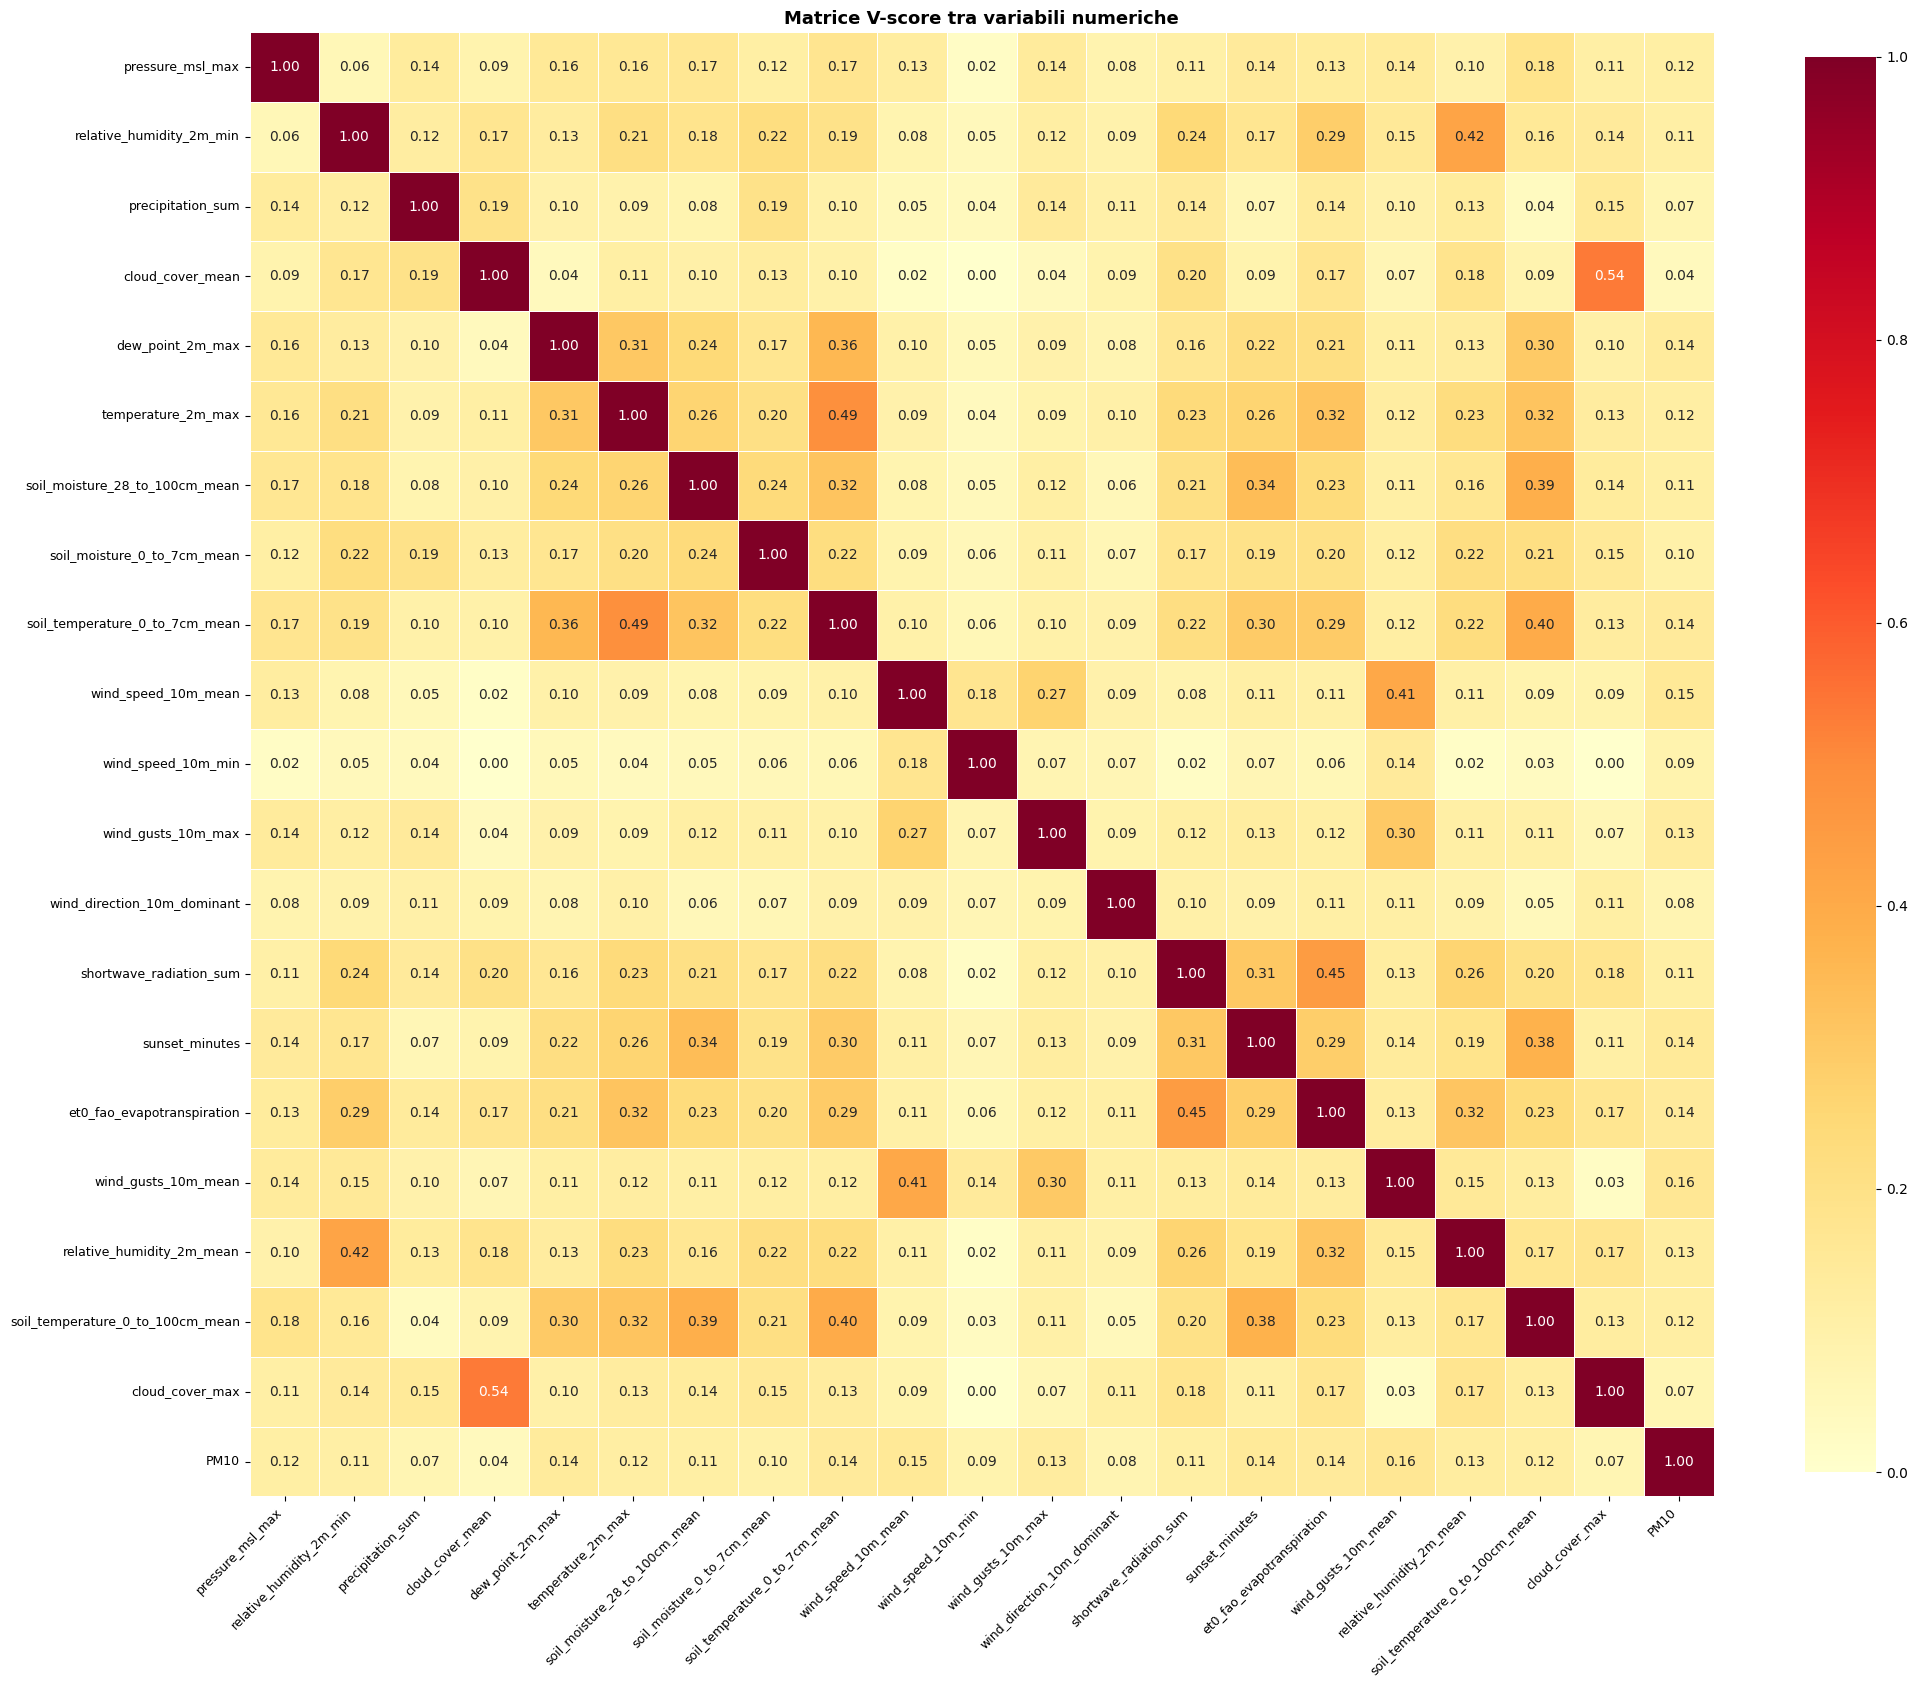

                              var1                              var2    vscore
0                 cloud_cover_mean                   cloud_cover_max  0.538798
1               temperature_2m_max    soil_temperature_0_to_7cm_mean  0.488705
2          shortwave_radiation_sum        et0_fao_evapotranspiration  0.451481
3         relative_humidity_2m_min         relative_humidity_2m_mean  0.422875
4              wind_speed_10m_mean               wind_gusts_10m_mean  0.409464
5   soil_temperature_0_to_7cm_mean  soil_temperature_0_to_100cm_mean  0.401022
6   soil_moisture_28_to_100cm_mean  soil_temperature_0_to_100cm_mean  0.386302
7                   sunset_minutes  soil_temperature_0_to_100cm_mean  0.376116
8                 dew_point_2m_max    soil_temperature_0_to_7cm_mean  0.357605
9   soil_moisture_28_to_100cm_mean                    sunset_minutes  0.341252
10              temperature_2m_max  soil_temperature_0_to_100cm_mean  0.319746
11              temperature_2m_max        et0_fao_ev

In [20]:
df_vscore = df_final.copy()

list_var_num = [
    col for col in df_vscore.select_dtypes(include='number').columns
    if col != 'PM10_target'
]

# --- Binning ---
for k in list_var_num:
    q = min(20, df_vscore[k].nunique())
    if q > 1:
        df_vscore[k] = pd.qcut(df_vscore[k], q=q, duplicates='drop')
        df_vscore[k] = df_vscore[k].map({
            val: 'bin' + f'{kk}'.zfill(2)
            for kk, val in enumerate(sorted(df_vscore[k].dropna().unique()))
        })

# --- Funzione V-score tra due variabili qualsiasi ---
def compute_vscore(df, var1, var2):
    df_contingency = (
        df.groupby([var1, var2])
        .size()
        .unstack()
        .replace(0, np.nan)
        .dropna(axis=0, how='all')
        .dropna(axis=1, how='all')
        .fillna(0)
        .astype(int)
    )

    r, c = df_contingency.shape
    n = df_contingency.sum().sum()

    if r > 1 and c > 1 and n > 0:
        vscore = scp_cont.association(df_contingency.values, method="tschuprow")
        num = max(0,
            vscore**2 * np.sqrt((c - 1) * (r - 1)) * (n - 1)
            - (r - 1) * (c - 1)
        )
        den = min((r - 1) * (n - c), (c - 1) * (n - r))
        return np.sqrt(num / den) if den > 0 else np.nan
    return np.nan

# --- Matrice completa ---
all_vars = list_var_num  # puoi aggiungere 'PM10_target' se vuoi includerla

matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for var1, var2 in combinations(all_vars, 2):
    v = compute_vscore(df_vscore, var1, var2)
    matrix.loc[var1, var2] = v
    matrix.loc[var2, var1] = v  # simmetrica

for var in all_vars:
    matrix.loc[var, var] = 1.0

# --- Heatmap ---


plt.figure(figsize=(max(10, len(all_vars)), max(8, len(all_vars) - 2)))
sns.heatmap(
    matrix.astype(float),
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    vmin=0, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Matrice V-score tra variabili numeriche", fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("../immagini/vscore_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Coppie più correlate (opzionale, utile per ispezione rapida) ---
pairs = (
    matrix.where(np.triu(np.ones(matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ['var1', 'var2', 'vscore']
pairs = pairs.sort_values('vscore', ascending=False).reset_index(drop=True)
print(pairs.head(20))

## Info value


In [ ]:
features = list_var_num
target = 'PM10_target'  # 1 = sopra soglia, 0 = sotto

# prendi solo le colonne che ti servono
df_sub = df_final[features + [target]]

# calcolo IV solo su queste
df_iv = sc.iv(df_sub, y=target)

In [ ]:
df_iv

,variable,info_value
7,precipitation_sum,1.554258
15,cloud_cover_max,1.043735
13,PM10,0.921836
20,wind_speed_10m_min,0.751508
16,wind_gusts_10m_max,0.630181
9,pressure_msl_max,0.439482
0,soil_moisture_28_to_100cm_mean,0.356359
11,sunset_minutes,0.352242
12,dew_point_2m_max,0.294795
19,temperature_2m_max,0.255658


## df_metrics

In [ ]:
df_metrics = (
    df_pearson
    .merge(df_spearman, on='variable', how='outer')
    .merge(df_vscore_result, on='variable', how='outer')
    .merge(df_iv, on='variable', how='outer')
)


In [ ]:
df_metrics.sort_values('v-score', ascending=False)


,variable,pearson_corr,spearman_corr,v-score,info_value
0,PM10,0.677313,0.352762,0.934636,0.921836
18,wind_gusts_10m_mean,-0.206818,-0.237375,0.337770,0.078055
11,soil_moisture_28_to_100cm_mean,0.119283,0.110901,0.284414,0.356359
19,wind_speed_10m_mean,-0.179370,-0.215085,0.281465,0.001844
14,sunset_minutes,-0.172652,-0.165416,0.263814,0.352242
12,soil_temperature_0_to_100cm_mean,-0.218928,-0.226913,0.262652,0.001844
9,shortwave_radiation_sum,-0.189769,-0.184021,0.242878,0.074092
7,relative_humidity_2m_mean,0.220754,0.233734,0.239634,0.001844
10,soil_moisture_0_to_7cm_mean,0.111167,0.075804,0.230801,0.010996
8,relative_humidity_2m_min,0.224389,0.219134,0.221414,0.004920


# Confronto e spiegazione

## PM10

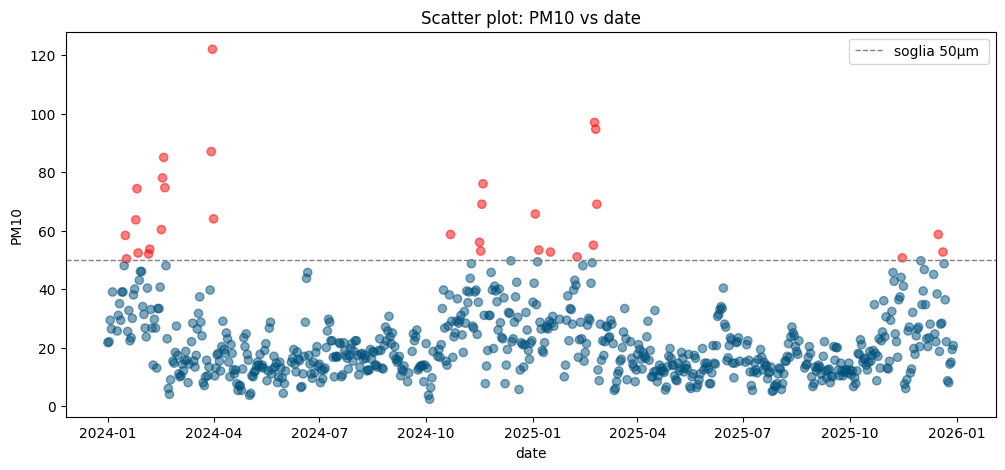

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', '#00517cff')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50μm ')

plt.xlabel('date')
plt.ylabel('PM10')
plt.title('Scatter plot: PM10 vs date')
plt.legend()

plt.show()

## Precipitaion_sum

Definizione: Somma delle precipitazioni giornaliere (incluse pioggia, rovesci e nevicate)  

Unità di misura: mm

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'precipitation_sum',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
5,precipitation_sum,-0.043941,-0.010557,0.04666,1.554258


Lettura dei risultati

La correlazione Pearson è leggermente negativa, quindi nei dati la precipitazione tende ad associarsi a una minore probabilità/concentrazione di PM10, ma il legame lineare è molto debole.

La Spearman è quasi nulla, quindi non emerge una relazione monotona semplice: più pioggia non implica meccanicamente meno PM10 in modo regolare.

Il punto forte è l’Information Value = 1.55, molto alto. Questo significa che, dopo il binning, precipitation_sum separa bene i giorni sopra/sotto soglia. Quindi la variabile è utile non perché abbia una relazione lineare forte, ma perché aiuta a distinguere condizioni meteorologiche favorevoli o sfavorevoli al superamento della soglia.

Questa è una motivazione importante: Pearson e Spearman bassi non invalidano la variabile, perché il modello sta predicendo una target binaria e può sfruttare soglie/non-linearità.

Interpretazione fisica

La precipitazione è rilevante perché contribuisce alla rimozione del particolato dall’atmosfera tramite wet deposition / wet scavenging. In pratica, la pioggia può catturare e rimuovere particelle sospese, riducendo la concentrazione di PM10.

La letteratura conferma che l’aumento della precipitazione può ridurre PM10 per deposizione umida; uno studio su simulazioni climatiche regionali europee afferma che l’aumento della precipitazione riduce PM10 tramite wet deposition (https://acp.copernicus.org/articles/21/415/2021/)

Un altro studio empirico mostra che l’effetto della pioggia sul PM non è sempre lineare: dipende dall’intensità della precipitazione, dalla concentrazione iniziale di particolato e dal tipo di particelle. In particolare, lo scavenging ratio del PM10 cresce con la precipitazione accumulata, e la pioggia può ridurre efficacemente il PM10, ma l’effetto varia in base alle condizioni iniziali (https://www.mdpi.com/2073-4433/12/6/759).



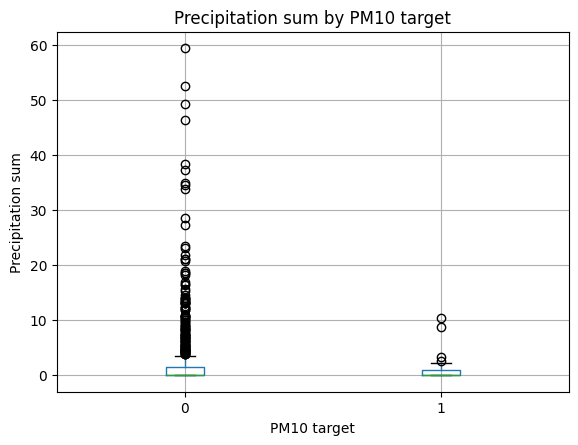

In [ ]:
df_final.boxplot(
    column='precipitation_sum',
    by='PM10_target'
)

plt.title('Precipitation sum by PM10 target')
plt.suptitle('')
plt.xlabel('PM10 target')
plt.ylabel('Precipitation sum')
plt.show()

Il grafico mostra che i superamenti della soglia di PM10 tendono a verificarsi soprattutto in giornate con precipitazioni assenti o molto basse. Questo risultato è coerente con il ruolo della pioggia come meccanismo di rimozione del particolato atmosferico tramite deposizione umida. Tuttavia, la relazione non appare lineare, e questo spiega perché Pearson e Spearman risultano bassi, mentre l’Information Value è elevato.

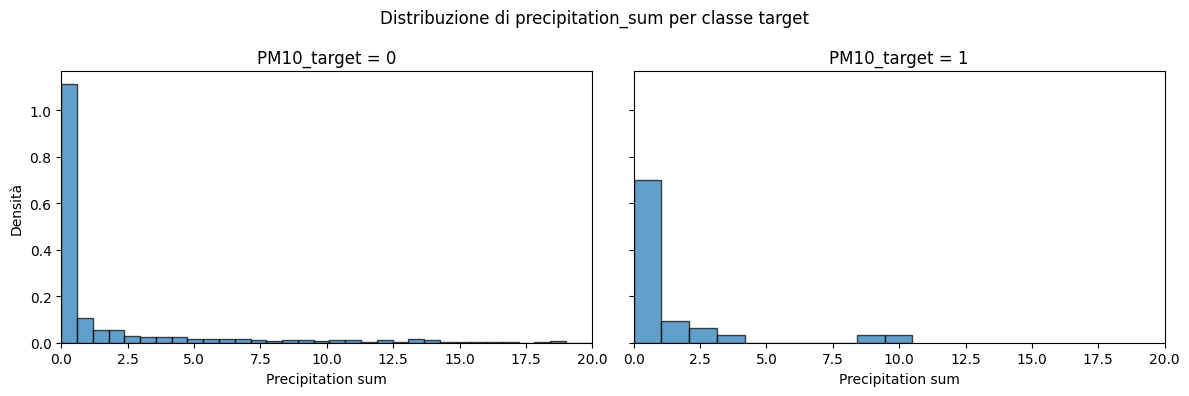

In [ ]:

x0 = df_final[df_final['PM10_target'] == 0]['precipitation_sum'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['precipitation_sum'].dropna()

xmin = df_final['precipitation_sum'].min()
xmax = df_final['precipitation_sum'].max()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=100, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('Precipitation sum')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=10, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('Precipitation sum')

axes[0].set_xlim(0, 20)
axes[1].set_xlim(0, 20)

plt.suptitle('Distribuzione di precipitation_sum per classe target')
plt.tight_layout()
plt.show()

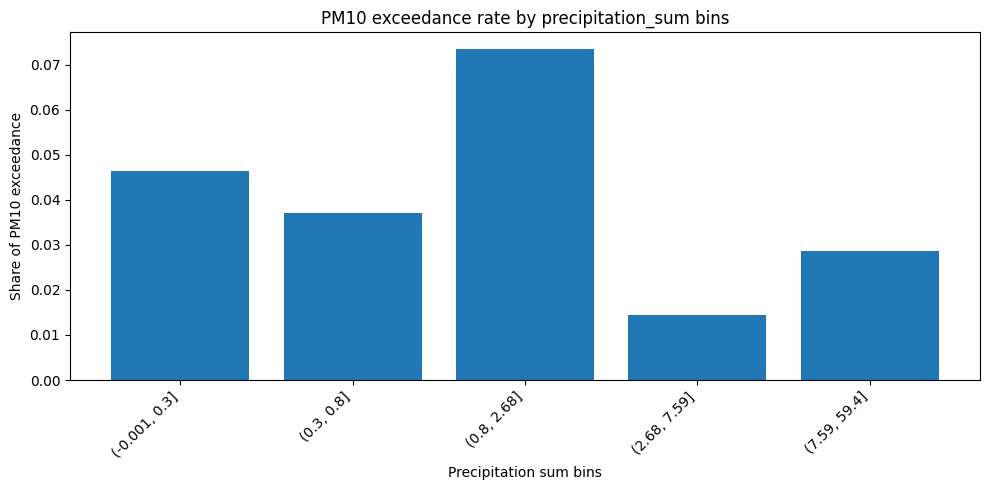

In [ ]:
df_plot = df_final[['precipitation_sum', 'PM10_target']].dropna().copy()

df_plot['precipitation_bin'] = pd.qcut(
    df_plot['precipitation_sum'],
    q=10,
    duplicates='drop'
)

target_rate = (
    df_plot
    .groupby('precipitation_bin', observed=False)['PM10_target']
    .mean()
    .reset_index()
)

target_rate['precipitation_bin'] = target_rate['precipitation_bin'].astype(str)

plt.figure(figsize=(10, 5))
plt.bar(target_rate['precipitation_bin'], target_rate['PM10_target'])

plt.xticks(rotation=45, ha='right')
plt.xlabel('Precipitation sum bins')
plt.ylabel('Share of PM10 exceedance')
plt.title('PM10 exceedance rate by precipitation_sum bins')
plt.tight_layout()
plt.show()

Data che la maggior parte delle osservazioni hanno un valore di precipitation sum compreso tra -0.0001 e 0.8, sono stati binnizzate in due sezioni, limitando il range. Tenendo conto del range di ciascun bin si può visualizzare la relazione decrescente tra share of PM10 exceedance e precipitation sum

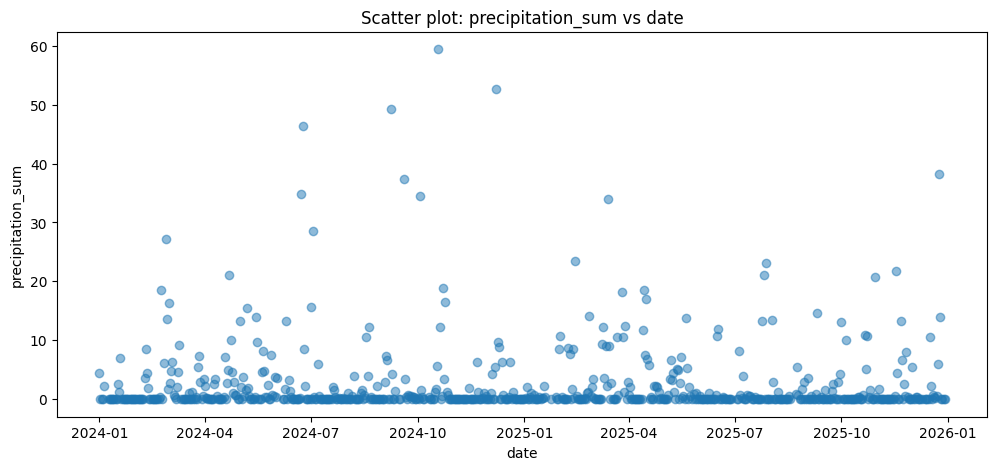

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['precipitation_sum'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('precipitation_sum')
plt.title('Scatter plot: precipitation_sum vs date')


plt.show()

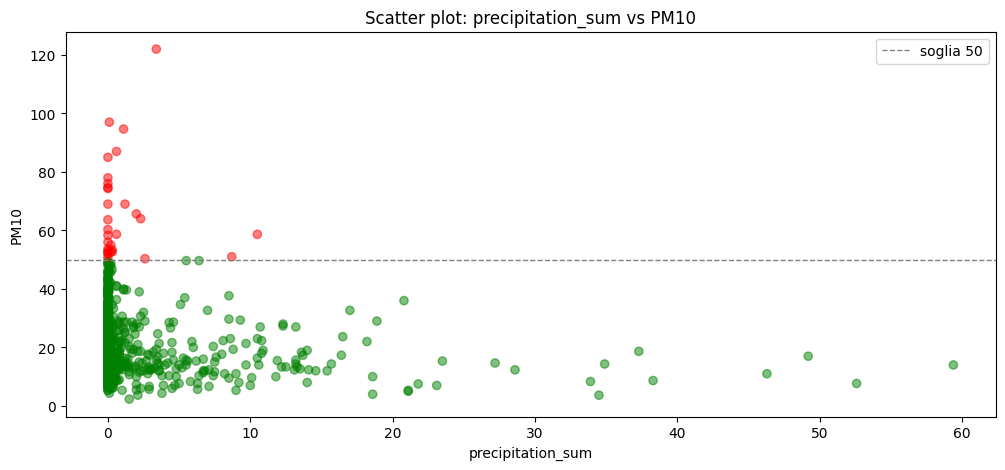

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['precipitation_sum'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('precipitation_sum')
plt.ylabel('PM10')
plt.title('Scatter plot: precipitation_sum vs PM10')
plt.legend()

plt.show()

## cloud_cover_max

Definizione : copertura nuvolosa totale in frazione di area  
Unità di misura: %

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'cloud_cover_max',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
1,cloud_cover_max,0.074247,0.094974,0.040251,1.043735


Lettura statistica  
Pearson positivo ma debole: maggiore copertura nuvolosa massima è associata a una lieve maggiore probabilità di superamento PM10.
Spearman positivo ma debole: anche la relazione monotona è debole, ma coerente nel segno.
V-score basso: l’associazione categoriale diretta è limitata.
Information Value alto: la variabile contiene informazione utile per separare giorni sopra/sotto soglia.  
cloud_cover_max è utile perché intercetta condizioni meteorologiche giornaliere associate ai superamenti, ma il suo effetto non è forte né isolabile in modo lineare.

Interpretazione fisica  
La copertura nuvolosa può essere collegata a condizioni atmosferiche che favoriscono l’accumulo del particolato: minore radiazione solare, maggiore umidità, minore rimescolamento verticale e condizioni più stabili. Non è necessariamente la nuvolosità in sé a far aumentare il PM10, ma il fatto che essa possa rappresentare un indicatore di specifiche configurazioni meteorologiche.  
La letteratura conferma che le concentrazioni di PM10 sono influenzate da condizioni meteorologiche come stabilità atmosferica, boundary layer, vento e precipitazioni; uno studio su contesti urbani mostra che i pattern di PM10 dipendono fortemente da condizioni locali e sinottiche, inclusa la stabilità atmosferica (https://www.sciencedirect.com/science/article/pii/S2590252024000448).  
Inoltre, studi su aerosol, cloud cover e radiazione mostrano che copertura nuvolosa, aerosol e vapore acqueo interagiscono nel determinare la radiazione superficiale, cioè una variabile legata ai processi atmosferici che influenzano anche dispersione e accumulo degli inquinanti (https://acp.copernicus.org/articles/25/1307/2025/).

La variabile cloud_cover_max è stata mantenuta perché rappresenta un indicatore delle condizioni atmosferiche giornaliere. Le correlazioni con la target sono positive ma deboli, quindi non emerge una relazione lineare forte. Tuttavia, l’Information Value elevato suggerisce che la variabile contribuisce a distinguere i giorni con e senza superamento della soglia di PM10. Questo risultato è coerente con l’idea che la copertura nuvolosa possa intercettare condizioni meteorologiche più ampie, come minore radiazione solare, maggiore stabilità atmosferica e minore dispersione degli inquinanti.

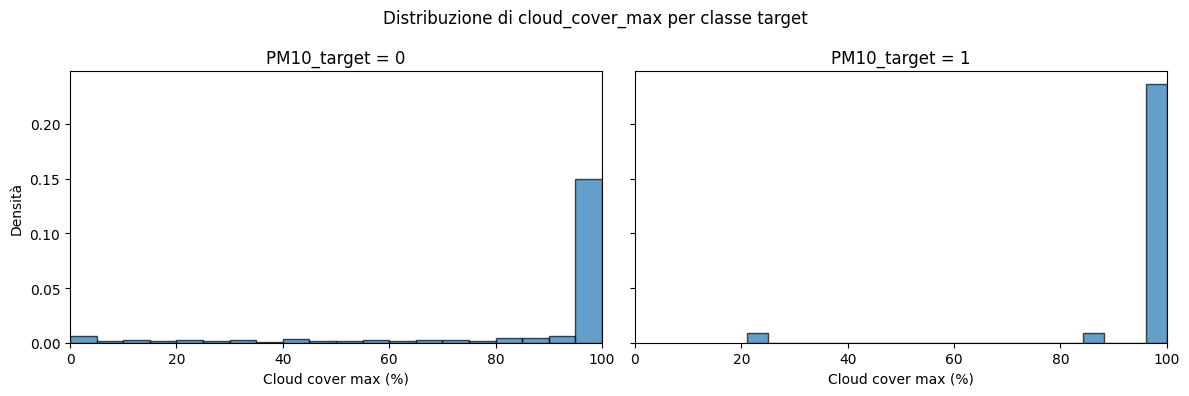

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['cloud_cover_max'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['cloud_cover_max'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('Cloud cover max (%)')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('Cloud cover max (%)')

axes[0].set_xlim(0, 100)
axes[1].set_xlim(0, 100)

plt.suptitle('Distribuzione di cloud_cover_max per classe target')
plt.tight_layout()
plt.show()

SAREBBE DA LEVARE 

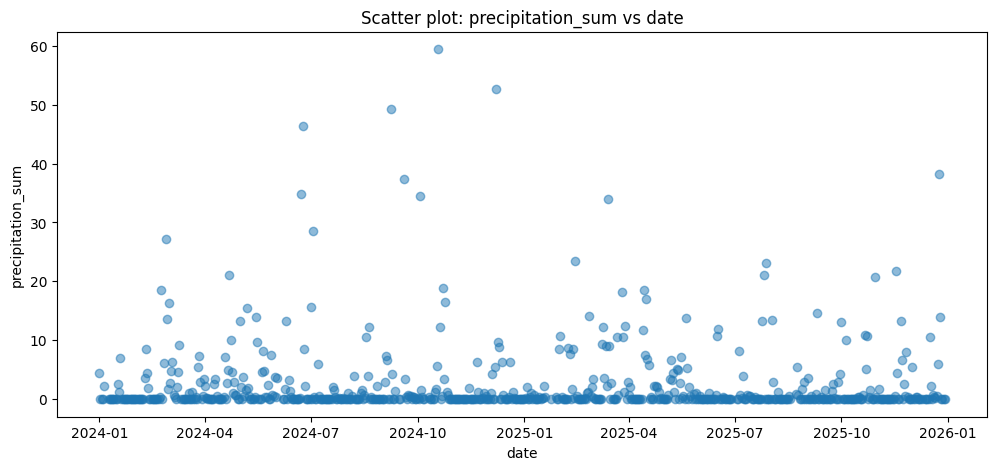

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['precipitation_sum'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('precipitation_sum')
plt.title('Scatter plot: precipitation_sum vs date')


plt.show()

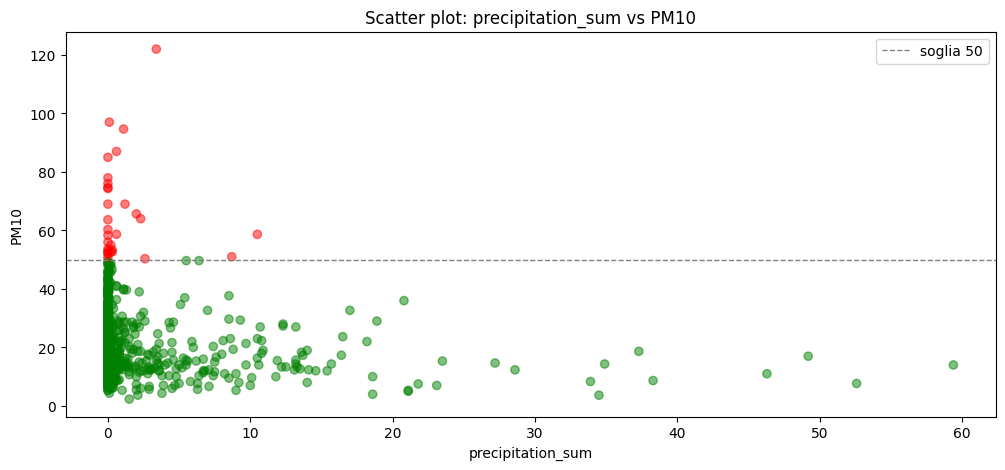

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['precipitation_sum'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('precipitation_sum')
plt.ylabel('PM10')
plt.title('Scatter plot: precipitation_sum vs PM10')
plt.legend()

plt.show()

## wind_speed_10m_min

Descrizione: Velocità del vento a 10 o 100 metri dal suolo. La velocità del vento a 10 metri è il livello standard.  
Unità di misura: km/h

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'wind_speed_10m_min',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
20,wind_speed_10m_min,-0.105989,-0.137145,0.102036,0.751508


Lettura statistica  
Pearson negativo: quando la velocità minima del vento aumenta, la probabilità di superamento PM10 tende a diminuire.  
Spearman negativo: conferma una relazione monotona negativa, anche se non fortissima.  
V-score = 0.102: associazione discreta, più alta rispetto a molte altre variabili.  
Information Value = 0.752: molto buono; la variabile distingue bene i giorni sopra/sotto soglia.

Interpretazione fisica  
Il vento favorisce la dispersione degli inquinanti. Se anche la velocità minima giornaliera del vento resta bassa, significa che durante la giornata ci sono momenti di stagnazione atmosferica. In queste condizioni il PM10 tende ad accumularsi vicino al suolo.

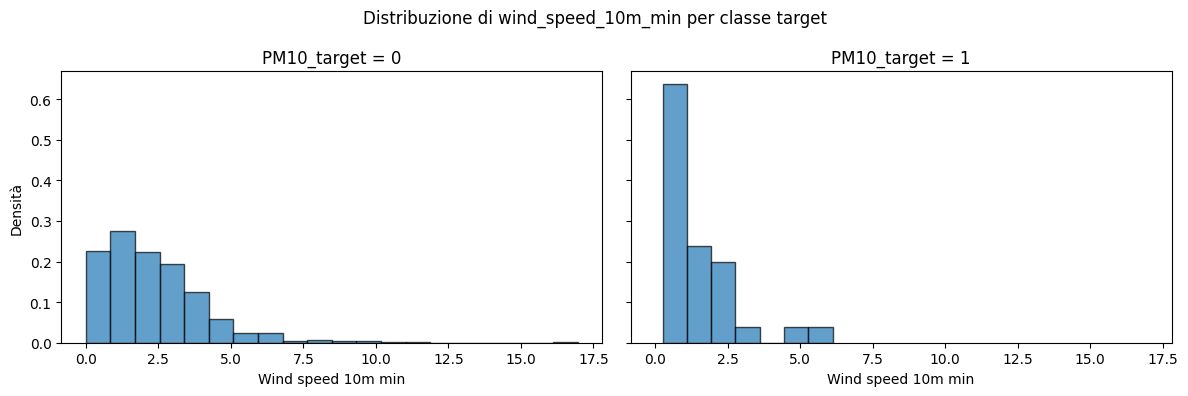

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['wind_speed_10m_min'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['wind_speed_10m_min'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('Wind speed 10m min')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=7, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('Wind speed 10m min')

plt.suptitle('Distribuzione di wind_speed_10m_min per classe target')
plt.tight_layout()
plt.show()

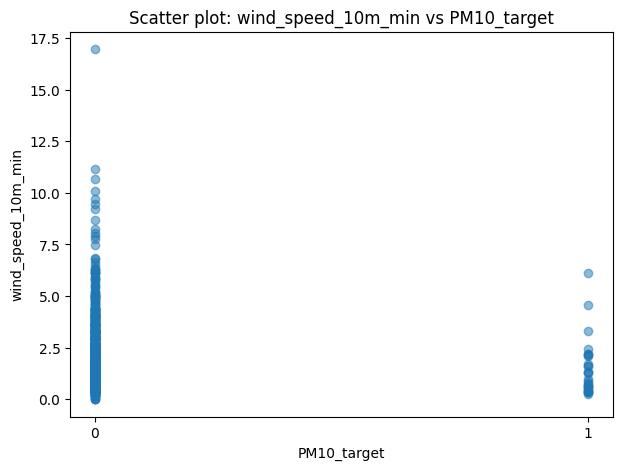

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['wind_speed_10m_min'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('wind_speed_10m_min')
plt.title('Scatter plot: wind_speed_10m_min vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

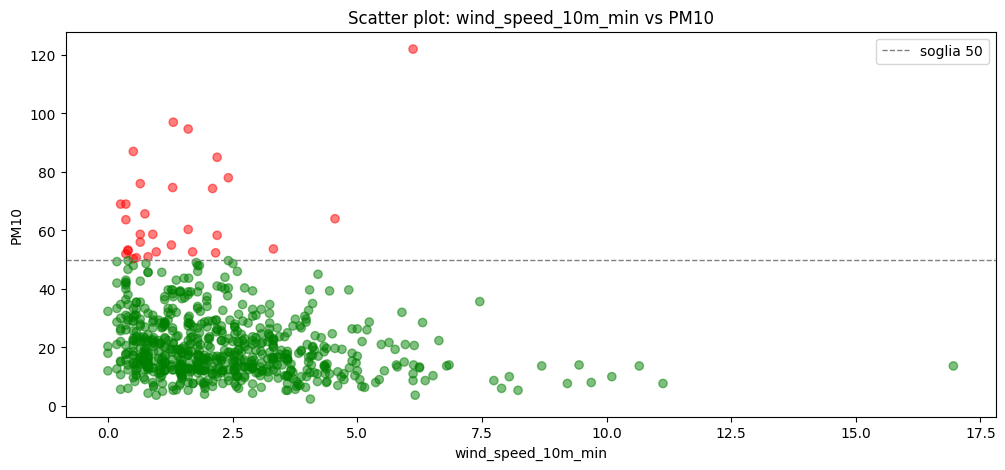

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['wind_speed_10m_min'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('wind_speed_10m_min')
plt.ylabel('PM10')
plt.title('Scatter plot: wind_speed_10m_min vs PM10')
plt.legend()

plt.show()

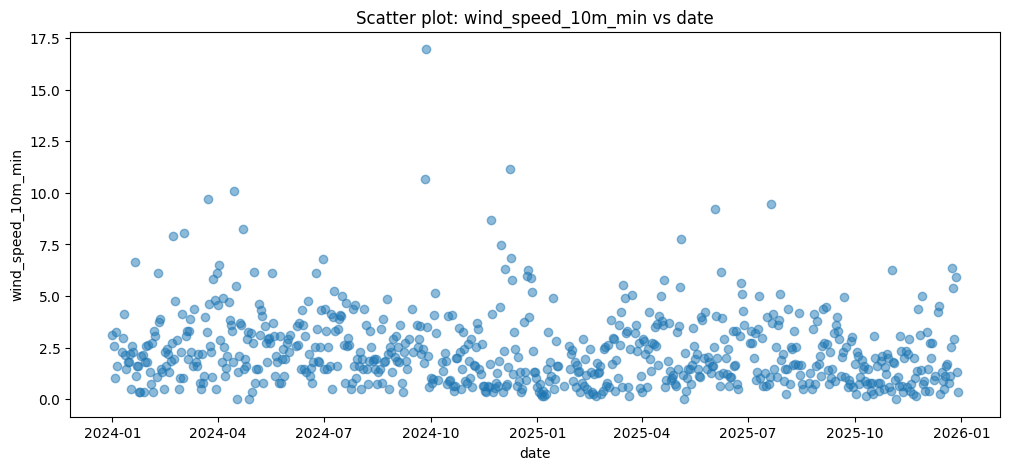

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['wind_speed_10m_min'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('wind_speed_10m_min')
plt.title('Scatter plot: wind_speed_10m_min vs date')


plt.show()

## wind_gusts_10m_max

Descrizione: raffiche di vento a 10 metri sopra terra   
Unità di misura: km/h

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'wind_gusts_10m_max',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
17,wind_gusts_10m_max,-0.152908,-0.172406,0.194113,0.630181


Pearson negativo: quando aumentano le raffiche massime, i superamenti PM10 tendono a diminuire.  
Spearman negativo: conferma che la relazione è anche monotona negativa.  
V-score = 0.194: associazione discreta, più alta rispetto a molte altre variabili.  
Information Value = 0.630: buono, quindi la variabile aiuta a distinguere giorni sopra/sotto soglia.

Interpretazione fisica:  
Le raffiche di vento più intense favoriscono la dispersione del particolato atmosferico. Al contrario, giornate senza raffiche significative sono più compatibili con condizioni di stagnazione atmosferica, che favoriscono l’accumulo di PM10 vicino al suolo.

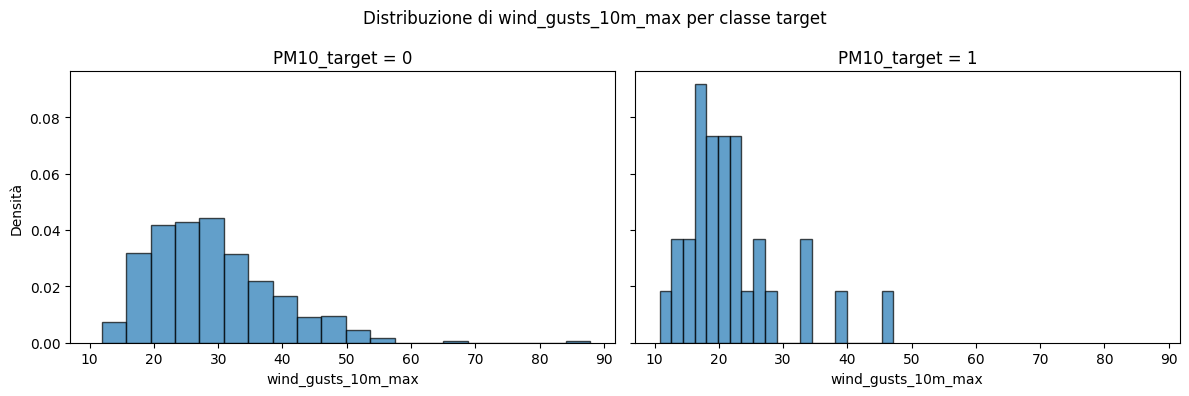

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['wind_gusts_10m_max'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['wind_gusts_10m_max'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('wind_gusts_10m_max')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('wind_gusts_10m_max')

plt.suptitle('Distribuzione di wind_gusts_10m_max per classe target')
plt.tight_layout()
plt.show()

La distribuzione mostra che i superamenti di PM10 sono concentrati soprattutto in giornate con raffiche massime relativamente basse. Questo conferma il ruolo del vento come meccanismo di dispersione degli inquinanti: in assenza di raffiche intense, l’atmosfera tende a essere più stagnante e il particolato può accumularsi più facilmente.

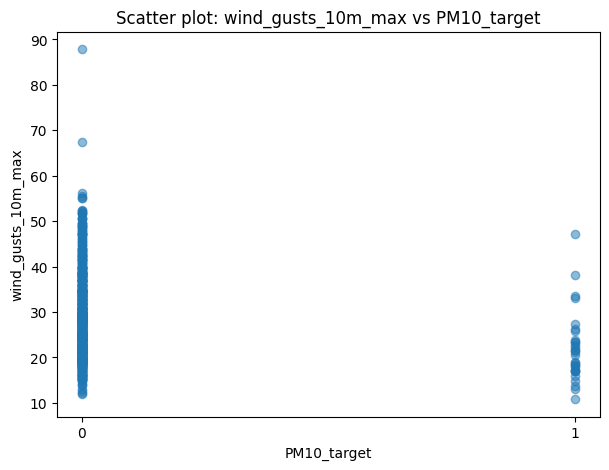

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['wind_gusts_10m_max'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('wind_gusts_10m_max')
plt.title('Scatter plot: wind_gusts_10m_max vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

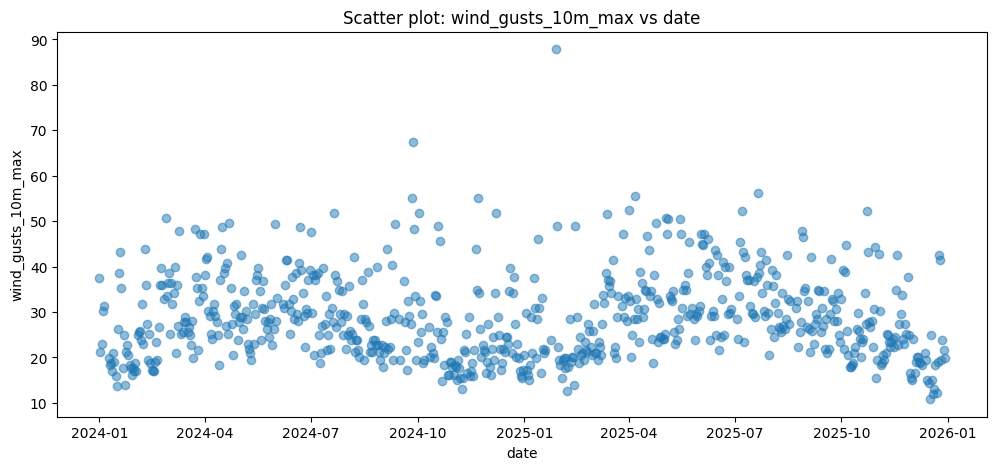

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['wind_gusts_10m_max'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('wind_gusts_10m_max')
plt.title('Scatter plot: wind_gusts_10m_max vs date')


plt.show()

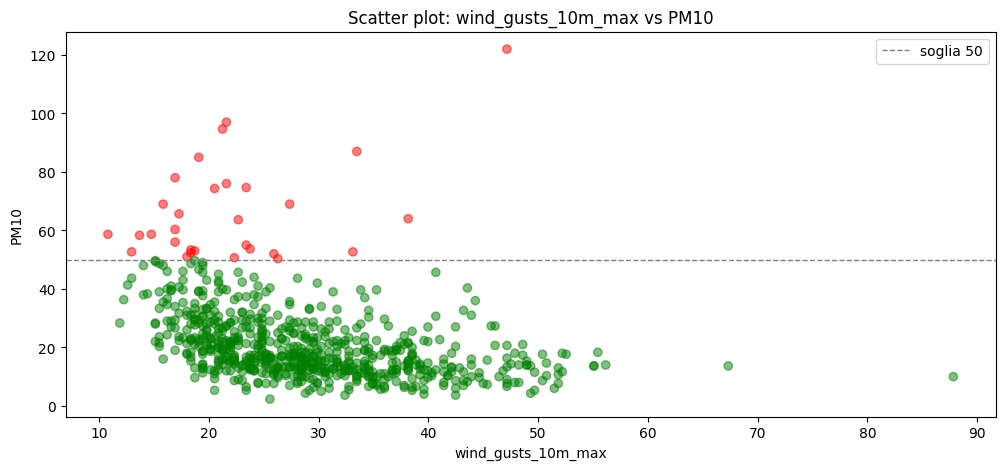

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['wind_gusts_10m_max'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('wind_gusts_10m_max')
plt.ylabel('PM10')
plt.title('Scatter plot: wind_gusts_10m_max vs PM10')
plt.legend()

plt.show()

## pressure_msl_max


Descrizione: Atmospheric air pressure reduced to mean sea level (msl).  
Unità di misura: hPA

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'pressure_msl_max',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
6,pressure_msl_max,0.128194,0.118041,0.159845,0.439482


Pearson: relazione positiva ma debole: quando la pressione massima giornaliera aumenta, tende ad aumentare anche la probabilità di superamento PM10, ma non in modo forte o perfettamente lineare.  
Spearman :anche la relazione monotona è positiva ma debole. Quindi non è solo un effetto lineare: in generale, valori più alti di pressione sembrano associarsi a un rischio leggermente maggiore di superamento.  
V-score : è una buona indicazione di associazione dopo discretizzazione. La pressione probabilmente lavora meglio per “fasce” o condizioni atmosferiche, più che come effetto continuo lineare.  
Information Value : è un valore buono. Significa che pressure_msl_max aiuta a distinguere i giorni sopra/sotto soglia, anche se non è tra le variabili più forti.

Interpretazione fisica:  
La pressione alta genera subsidenza: grandi masse d'aria in quota vengono "spinte" verso il basso su scala sinottica (centinaia di km).  
L'aria che scende si comprime e si riscalda per compressione adiabatica (come in una pompa da bici: comprimi il gas, si scalda). Questo riscaldamento avviene in quota, non al suolo.  
Si crea un'inversione termica: ad una certa altitudine (tipicamente 500–1500 m in pianura padana) trovi uno strato d'aria più calda di quella sottostante. Questo è paradossale rispetto al gradiente normale.  
L'inversione funziona da coperchio fisico: l'aria calda e leggera in quota blocca la risalita dell'aria fredda e densa dal basso. La convezione si ferma. Il rimescolamento verticale è inibito.  
Gli inquinanti si accumulano nello strato sottostante: tutto ciò che viene emesso (traffico, riscaldamento, industria) resta intrappolato in uno strato basso, che si chiama mixing layer, che può ridursi anche a poche centinaia di metri.  

Perché la pianura padana è particolarmente vulnerabile:  
La morfologia del bacino (Alpi a nord e ovest, Appennini a sud) amplifica questo meccanismo: non c'è ventilazione laterale significativa, e il mixing layer compresso accumula concentrazioni di PM10 che possono salire rapidamente in pochi giorni di anticiclone persistente.


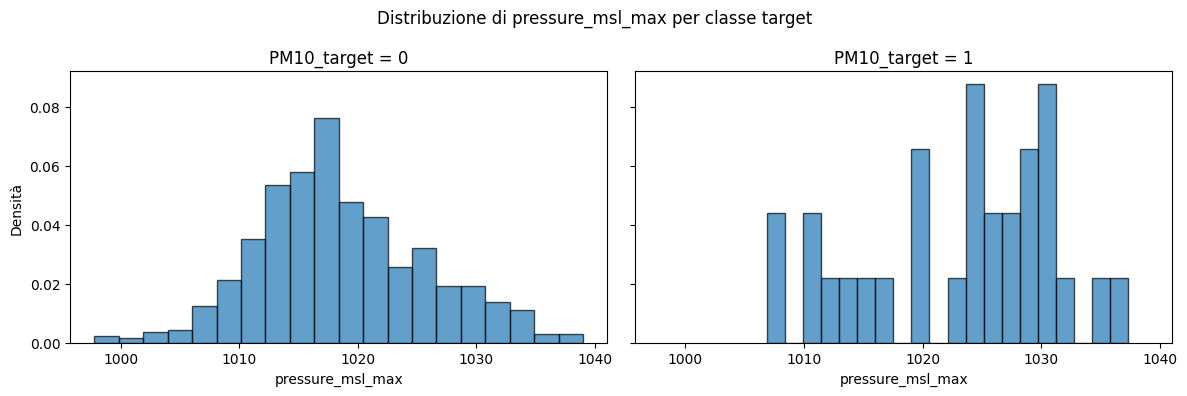

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['pressure_msl_max'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['pressure_msl_max'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('pressure_msl_max')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('pressure_msl_max')

plt.suptitle('Distribuzione di pressure_msl_max per classe target')
plt.tight_layout()
plt.show()

La classe 1 è chiaramente spostata verso valori più alti di pressione (1020–1035 hPa), confermando visivamente la separazione attesa.La classe 1 è chiaramente spostata verso valori più alti di pressione (1020–1035 hPa), confermando visivamente la separazione attesa. La classe 0 è centrata intorno a 1015–1018 hPa con distribuzione più regolare; l'irregolarità della classe 1 è semplicemente rumore da campione piccolo (70 obs).

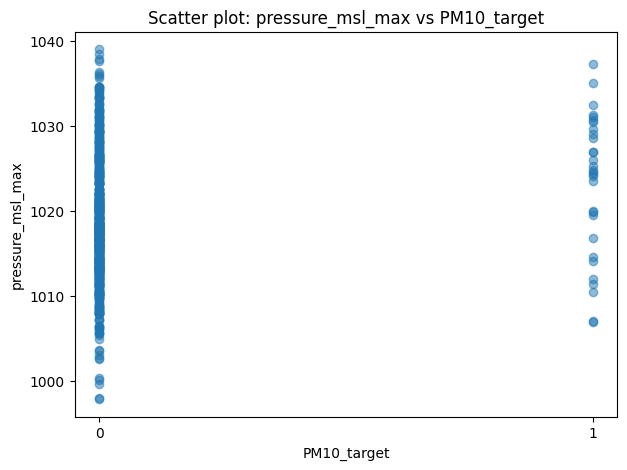

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['pressure_msl_max'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('pressure_msl_max')
plt.title('Scatter plot: pressure_msl_max vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

La classe 1 è visibilmente concentrata nella fascia 1020–1035 hPa, mentre la classe 0 copre un range molto più ampio scendendo fino a 998 hPa.La classe 1 è visibilmente concentrata nella fascia 1020–1035 hPa, mentre la classe 0 copre un range molto più ampio scendendo fino a 998 hPa. La separazione è chiara: valori bassi di pressione appartengono quasi esclusivamente alla classe 0.

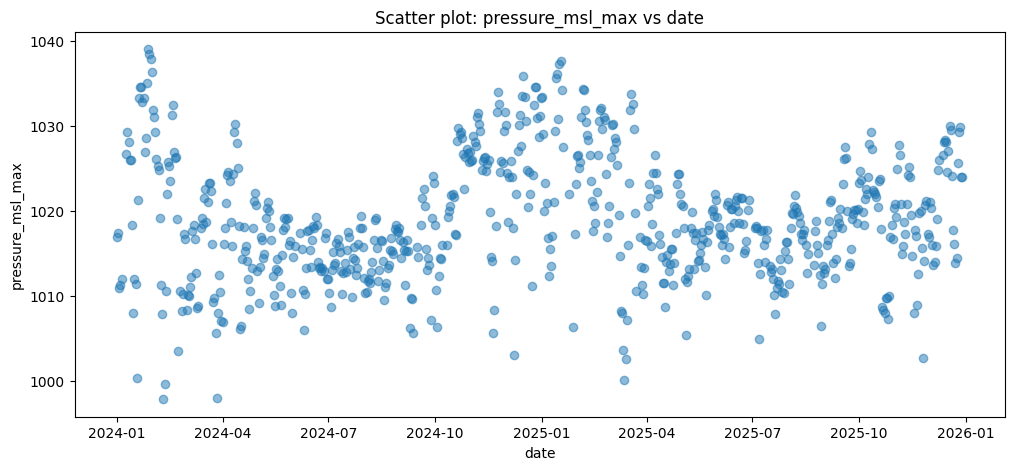

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['pressure_msl_max'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('pressure_msl_max')
plt.title('Scatter plot: pressure_msl_max vs date')


plt.show()

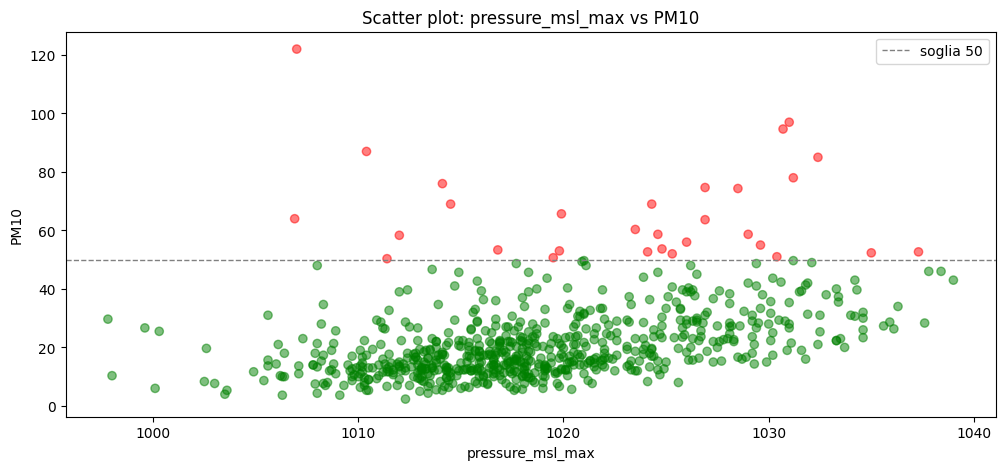

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['pressure_msl_max'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('pressure_msl_max')
plt.ylabel('PM10')
plt.title('Scatter plot: pressure_msl_max vs PM10')
plt.legend()

plt.show()

## soil_moisture_28_to_100cm_mean

Descrizione: Average soil water content as volumetric mixing ratio at  28-100 cm depths.  
Unità di misura: m^3 / m^3

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'soil_moisture_28_to_100cm_mean',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
11,soil_moisture_28_to_100cm_mean,0.119283,0.110901,0.284414,0.356359


Pearson (0.119) e Spearman (0.111) sono bassi e concordi, come nel caso della pressione. Anche qui la relazione non è lineare diretta, il che è atteso: l'umidità del suolo non agisce sul PM10 in modo immediato ma attraverso meccanismi indiretti.  
V di Cramér (0.284): sorprendentemente elevato per una variabile che fisicamente sembra lontana dal PM10. Suggerisce che la distribuzione della variabile cambia in modo marcato tra le due classi.  
Information Value (0.356): in fascia "strong predictor".

Interpretazione fisica:  
Alta umidità del suolo negli strati profondi (28–100 cm) → indicatore di stagione umida o recente precipitazione prolungata → condizioni meteorologiche che tipicamente non favoriscono l'accumulo di PM10.  

E viceversa: suolo secco in profondità → periodo secco prolungato → assenza di precipitazioni lavanti → atmosfera stabile → accumulo di PM10. L'umidità del suolo profondo è un integratore temporale delle condizioni meteorologiche recenti, molto meno volatile della pressione giornaliera. Reagisce lentamente, quindi riflette lo stato climatico delle settimane precedenti, non solo del giorno.

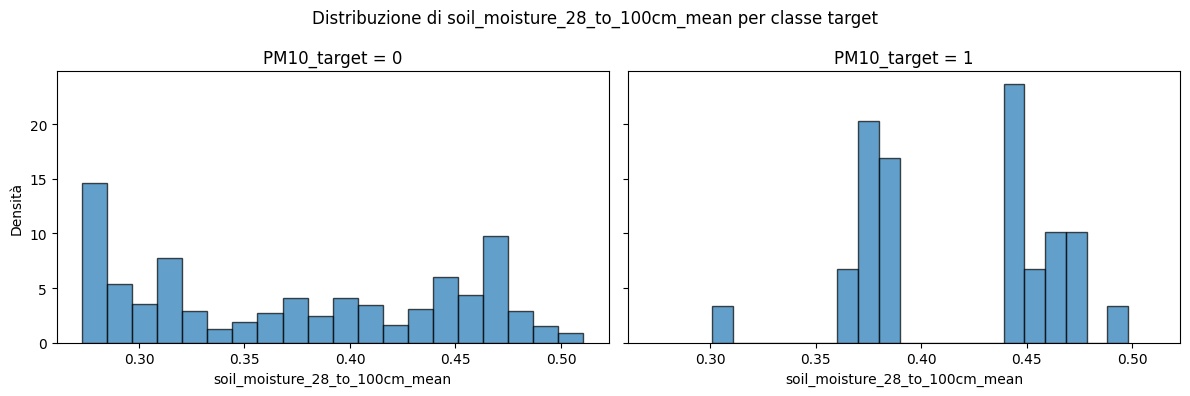

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['soil_moisture_28_to_100cm_mean'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['soil_moisture_28_to_100cm_mean'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('soil_moisture_28_to_100cm_mean')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('soil_moisture_28_to_100cm_mean')

plt.suptitle('Distribuzione di soil_moisture_28_to_100cm_mean per classe target')
plt.tight_layout()
plt.show()

La classe 0 ha una distribuzione bimodale con un picco importante sui valori bassi (~0.27) e uno sui valori alti (~0.46), coprendo un range ampio. La classe 1 invece è concentrata nella fascia 0.37–0.47, assente sui valori molto bassi. Questo è controintuitivo rispetto all'ipotesi iniziale (suolo secco → PM10 alto): i superamenti sembrano associarsi a valori medi-alti di umidità, non ai minimi. Potrebbe indicare che questa variabile cattura principalmente la stagionalità invernale (suolo umido + atmosfera stabile = condizioni tipiche degli episodi di PM10 in pianura padana) più che un effetto diretto dell'umidità sul particolato. La collinearità con variabili stagionali o di temperatura è 0.4 circa (con sunset minutes, soil temperature e dew point, tutte variabili che possono rappresentare la stagionalità)

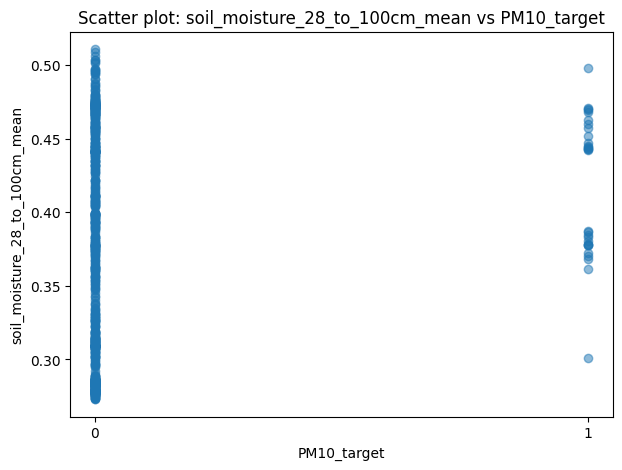

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['soil_moisture_28_to_100cm_mean'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('soil_moisture_28_to_100cm_mean')
plt.title('Scatter plot: soil_moisture_28_to_100cm_mean vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

Lo scatter conferma quanto visto nell'istogramma: la classe 1 non tocca quasi mai i valori bassi (<0.35) che invece sono abbondantissimi nella classe 0. La classe 0 copre tutto il range 0.27–0.51, mentre la classe 1 è compressa tra 0.36 e 0.50. Il segnale c'è, ma è asimmetrico: i valori bassi di umidità escludono il superamento, ma i valori alti non lo garantiscono affatto — il che spiega le correlazioni lineari basse nonostante un IV discreto.

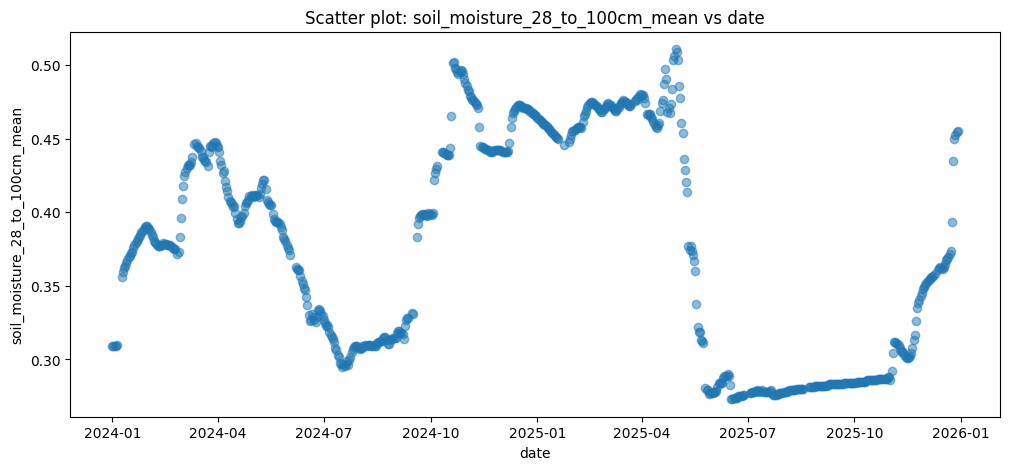

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['soil_moisture_28_to_100cm_mean'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('soil_moisture_28_to_100cm_mean')
plt.title('Scatter plot: soil_moisture_28_to_100cm_mean vs date')


plt.show()

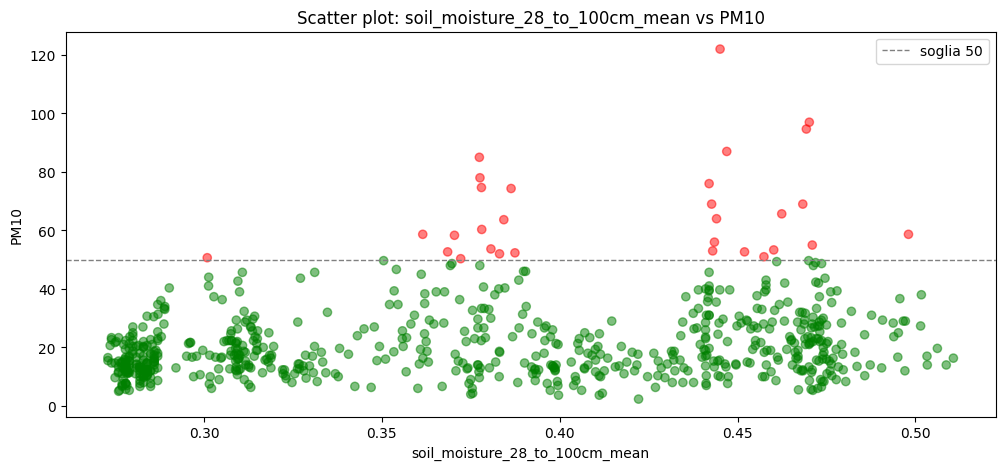

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['soil_moisture_28_to_100cm_mean'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('soil_moisture_28_to_100cm_mean')
plt.ylabel('PM10')
plt.title('Scatter plot: soil_moisture_28_to_100cm_mean vs PM10')
plt.legend()

plt.show()

Descrizione: minuti passati da mezzanotte fino all'alba
Unità di misura: minuti

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'sunset_minutes',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
14,sunset_minutes,-0.172652,-0.165416,0.263814,0.352242


Pearson e Spearman sono negativi: tramonto anticipato → giornate corte → stagione invernale → accumulo di PM10. La correlazione lineare è debole ma la direzione è fisica­mente sensata.  
V di Cramér è discreto, indica che la distribuzione della variabile cambia tra le due classi in modo non trascurabile.  
Information Value: fascia "strong predictor", la variabile porta informazione reale sul target.

Interpretazione fisica: 
Il punto critico è che sunset_minutes è una funzione deterministica del calendario — non misura nessun processo fisico diretto sul PM10, ma riassume la stagionalità. L'inverno porta simultaneamente giornate corte, inversioni termiche, riscaldamento domestico e scarsa dispersione atmosferica. La variabile cattura tutto questo in modo indiretto.

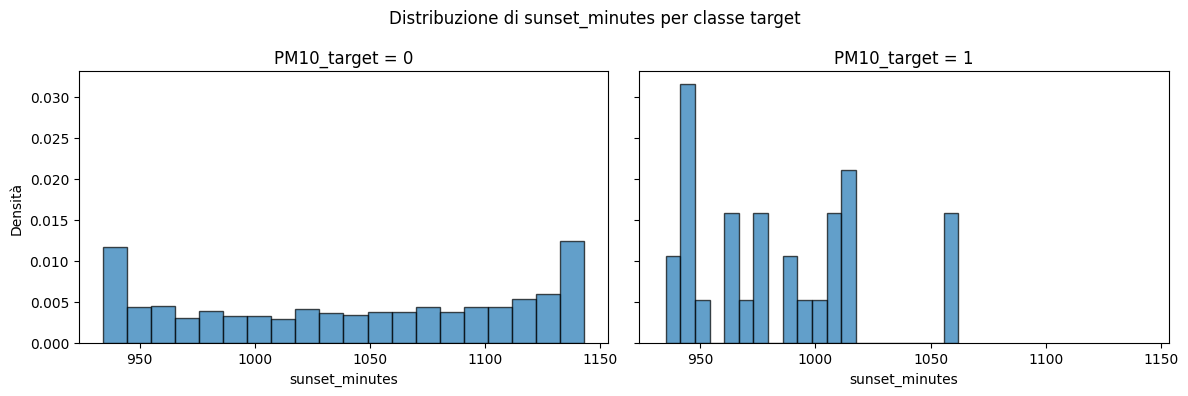

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['sunset_minutes'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['sunset_minutes'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('sunset_minutes')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('sunset_minutes')

plt.suptitle('Distribuzione di sunset_minutes per classe target')
plt.tight_layout()
plt.show()

la classe 1 è quasi assente oltre i 1070 minuti (giornate lunghe, estate/primavera), concentrandosi nella fascia 930–1060. Però la separazione non è netta come atteso: la classe 0 ha anch'essa un picco sui valori bassi (~940) e una distribuzione quasi piatta su tutto il range.  
Il dato più interessante è che la classe 1 sparisce completamente oltre ~1070, mentre la classe 0 arriva fino a 1150 — questo asimmetria è il vero segnale predittivo: l'estate esclude i superamenti, ma l'inverno non li garantisce affatto.

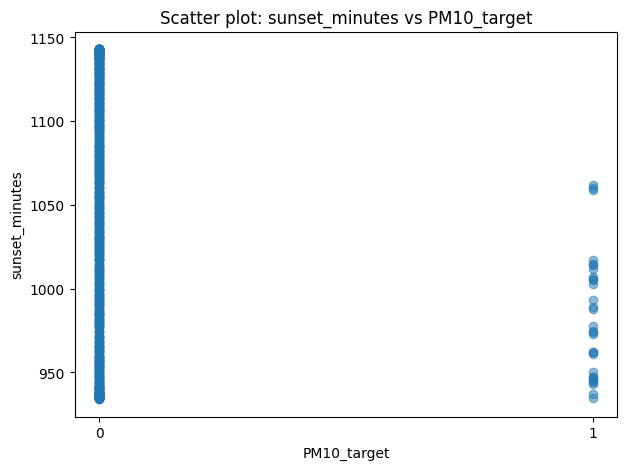

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['sunset_minutes'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('sunset_minutes')
plt.title('Scatter plot: sunset_minutes vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

La variabile funziona più come filtro esclusivo (estate = impossibile superamento) che come predittore positivo dell'evento.

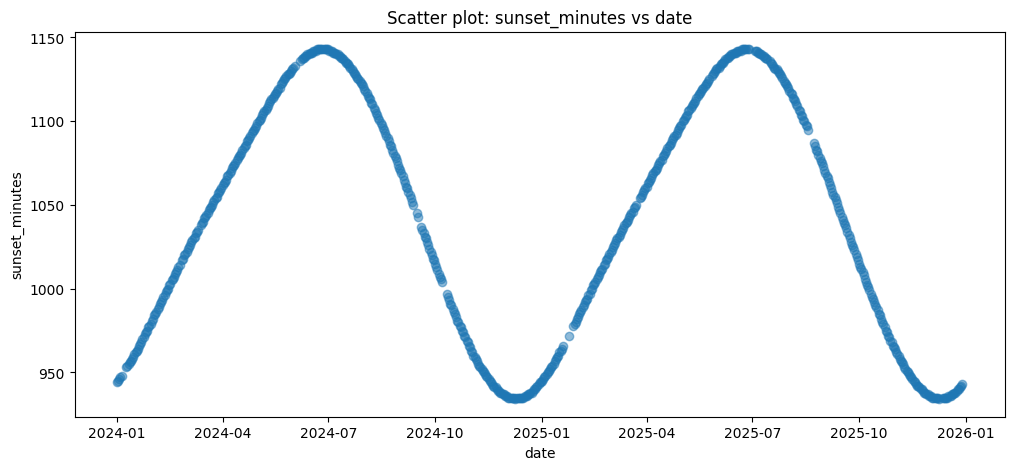

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['sunset_minutes'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('sunset_minutes')
plt.title('Scatter plot: sunset_minutes vs date')


plt.show()

## dew_point_2m_max

Descrizione: Dew point temperature at 2 meters above ground  
Unità di misura: °C  

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'dew_point_2m_max',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
3,dew_point_2m_max,-0.146463,-0.157416,0.215686,0.294795


Pearson e Spearman sono negativi e di magnitudine simile alle variabili precedenti. La direzione negativa significa che valori bassi di punto di rugiada sono associati al superamento di PM10.  
V di Cramér il più basso finora, separazione tra classi meno marcata.  
Information Value scende sotto 0.3, convenzionalmente il confine tra "medium" e "strong predictor". È la variabile più debole del set finora.

Interpretazione fisica:   
I valori molto bassi (<2°C) corrispondono ad aria continentale fredda e secca, spesso associata a vento e advection di masse d'aria da est o nord-est. Queste situazioni, pur essendo invernali, portano rimescolamento e ventilazione — condizioni che non favoriscono l'accumulo.  
La fascia 5–15°C è invece quella tipica dell'anticiclone padano "umido": aria stagnante, nebbia, inversione termica persistente, assenza di precipitazioni significative. È la condizione classica degli episodi acuti di PM10 in pianura padana — non il gelo secco, ma il grigio stagnante di gennaio con umidità relativa alta e vento assente.  
I valori alti (>18°C) appartengono all'estate, quando il calore genera convezione e dispersione verticale efficace — nessun superamento possibile.  

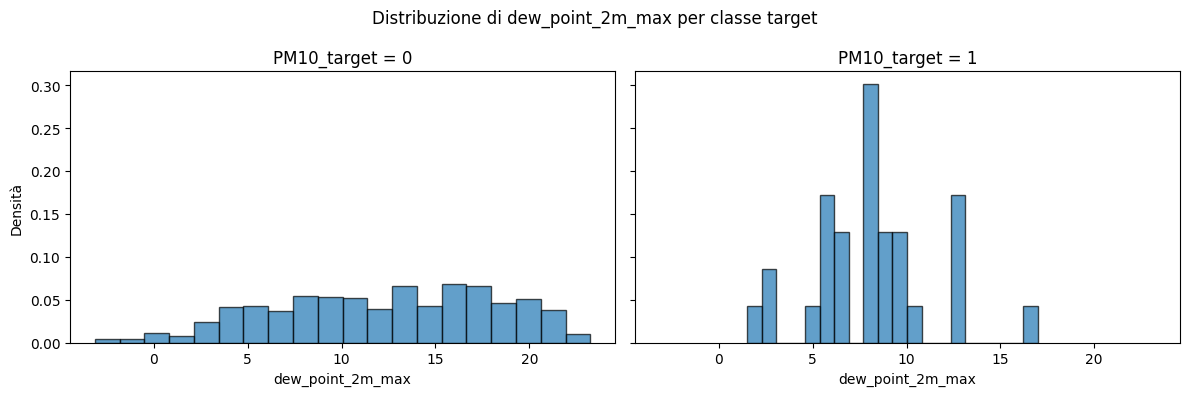

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['dew_point_2m_max'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['dew_point_2m_max'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('dew_point_2m_max')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('dew_point_2m_max')

plt.suptitle('Distribuzione di dew_point_2m_max per classe target')
plt.tight_layout()
plt.show()

La classe 1 è concentrata nella fascia 5–15°C con picco a ~8°C, completamente assente oltre i 18°C. La classe 0 copre tutto il range uniformemente fino a 23°C. La separazione non è netta ma il tetto a 18°C per la classe 1 è il segnale più robusto visivamente.

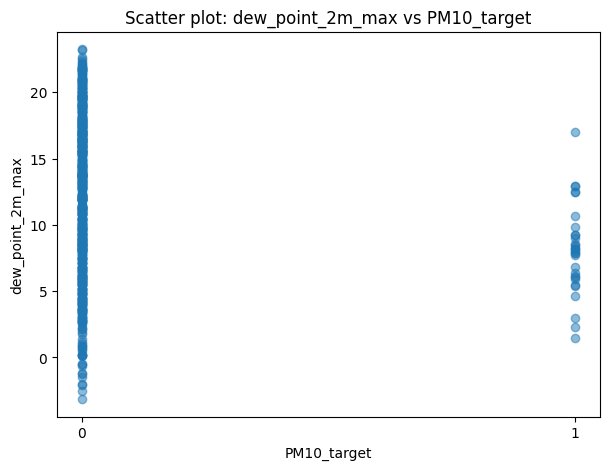

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['dew_point_2m_max'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('dew_point_2m_max')
plt.title('Scatter plot: dew_point_2m_max vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

La classe 1 è compressa tra ~2°C e 17°C, confermando il tetto superiore e l'assenza di valori molto bassi. La classe 0 copre tutto il range da -5°C a 23°C. Coerente con l'istogramma.

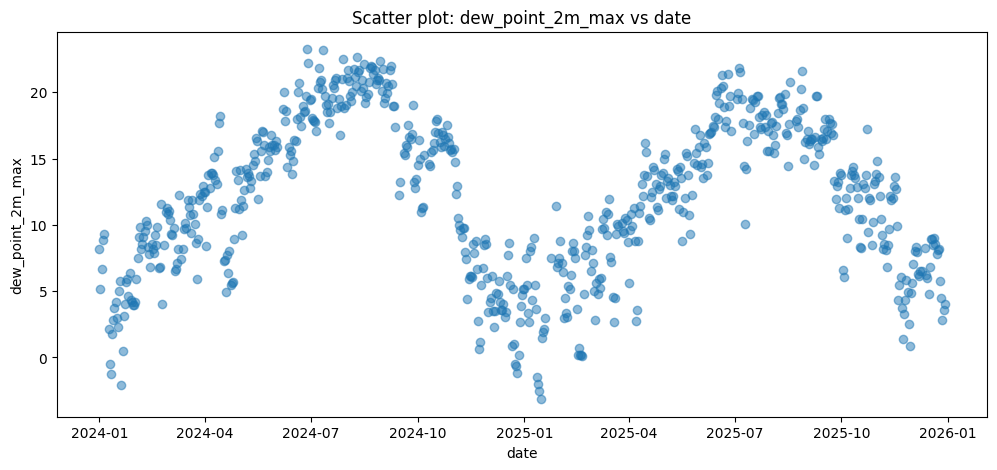

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['dew_point_2m_max'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('dew_point_2m_max')
plt.title('Scatter plot: dew_point_2m_max vs date')


plt.show()

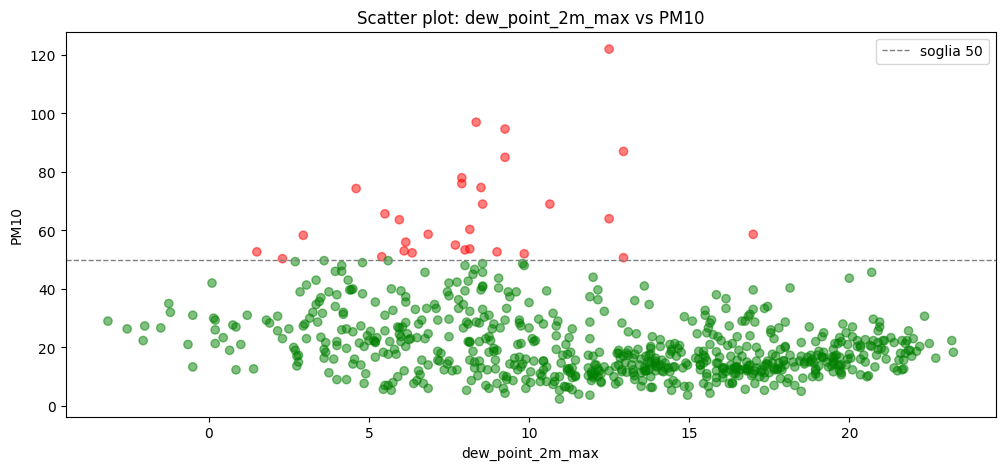

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['dew_point_2m_max'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('dew_point_2m_max')
plt.ylabel('PM10')
plt.title('Scatter plot: dew_point_2m_max vs PM10')
plt.legend()

plt.show()

## temperature_2m_max

Descrizione: Air temperature at 2 meters above ground
Unità di misura: °C

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'temperature_2m_max',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
15,temperature_2m_max,-0.188797,-0.192281,0.186867,0.255658


Pearson e Spearman sono i più alti in valore assoluto finora, e negativi: temperatura massima bassa → maggiore probabilità di superamento PM10. È la correlazione lineare più forte del set analizzato fino ad ora.  
V di Cramér :paradossalmente il più basso del set. La discrepanza con Pearson/Spearman è interessante: la relazione è più monotona che non-lineare, il che giustifica correlazioni di rango più alte ma V-score più basso.  
Information Value: il più basso finora, appena sopra la soglia "medium predictor" (0.1–0.3). Nonostante le correlazioni lineari più forti, l'IV è inferiore — suggerisce che la separazione bin-per-bin non è concentrata ma distribuita uniformemente lungo il range, senza bin particolarmente discriminanti.

Interpretazione fisica:  
Temperatura massima bassa → stagione invernale → rimescolamento verticale ridotto, inversione termica frequente, riscaldamento domestico intenso → accumulo PM10.  
Ma come per sunset_minutes e dew_point_2m_max, c'è una forte componente stagionale. 

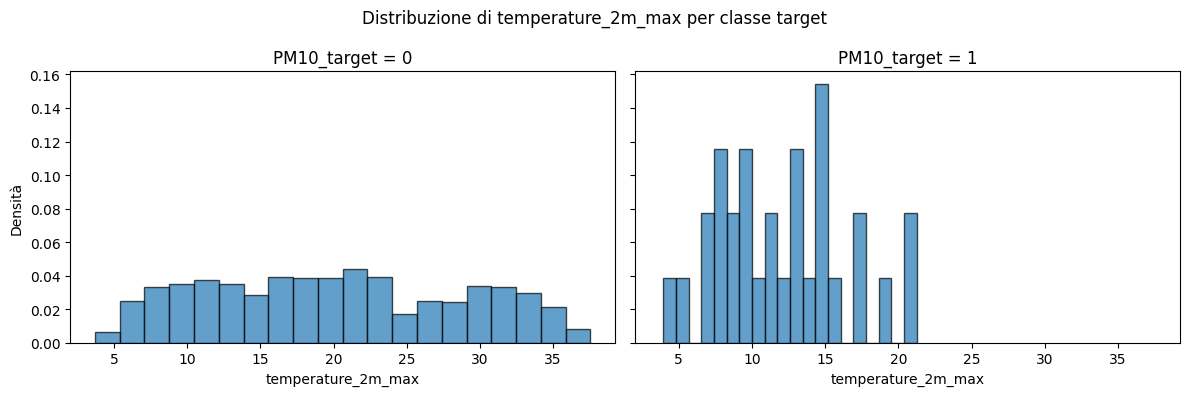

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['temperature_2m_max'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['temperature_2m_max'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('temperature_2m_max')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('temperature_2m_max')

plt.suptitle('Distribuzione di temperature_2m_max per classe target')
plt.tight_layout()
plt.show()

Deduzione confermata: la classe 1 è concentrata tra 5–22°C con picco a ~15°C, completamente assente oltre i 25°C. La classe 0 copre tutto il range fino a 37°C in modo quasi piatto. Il tetto a ~25°C è il segnale più netto — nessun superamento con temperature estive. La sovrapposizione nella fascia invernale è ampia, coerente con l'IV basso: la temperatura da sola non discrimina i giorni critici da quelli non critici in inverno.

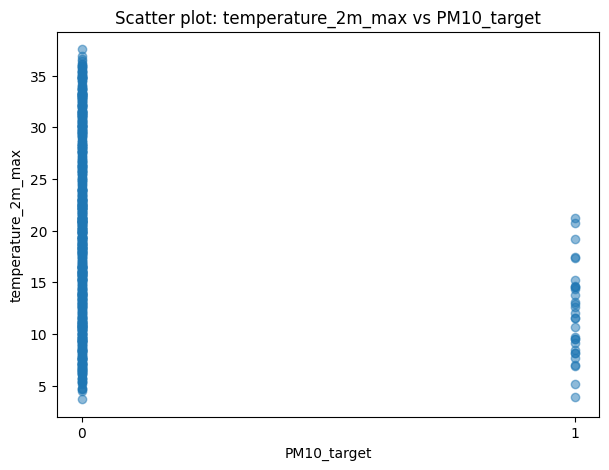

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['temperature_2m_max'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('temperature_2m_max')
plt.title('Scatter plot: temperature_2m_max vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

Conferma netta: la classe 1 è compressa tra 4°C e 22°C, con il tetto superiore ben visibile. La classe 0 arriva fino a 37°C. Identico pattern a dew_point_2m_max e sunset_minutes — le tre variabili stanno probabilmente catturando lo stesso segnale stagionale, vscore inferiore al 0.3

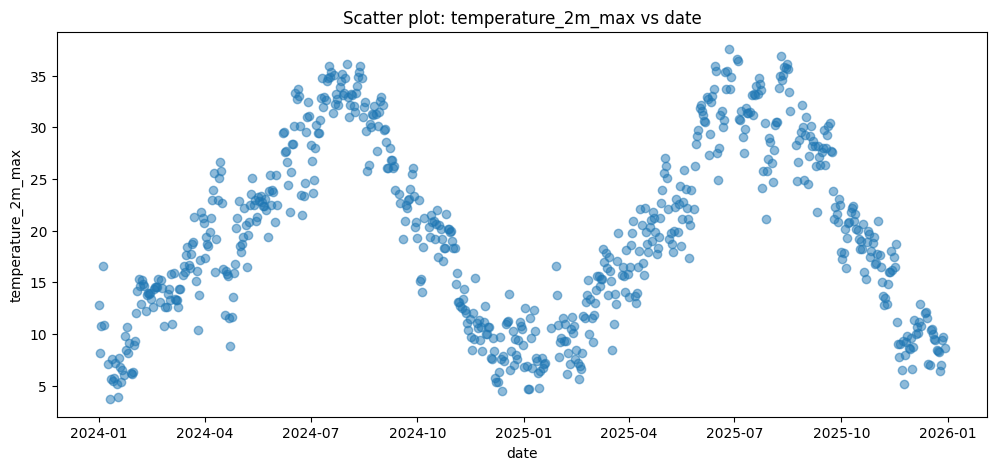

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['temperature_2m_max'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('temperature_2m_max')
plt.title('Scatter plot: temperature_2m_max vs date')


plt.show()

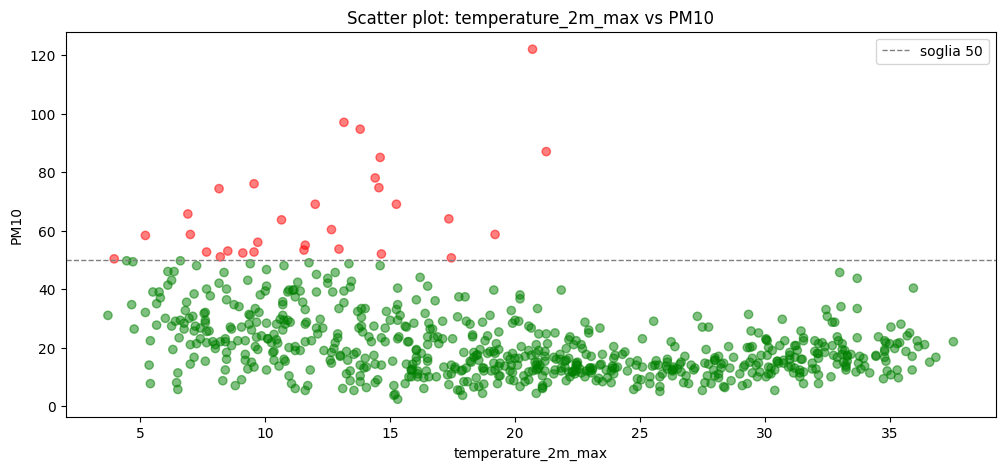

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['temperature_2m_max'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('temperature_2m_max')
plt.ylabel('PM10')
plt.title('Scatter plot: temperature_2m_max vs PM10')
plt.legend()

plt.show()

## shortwave_radiation_sum

Descrizione:  The sum of solar radiaion on a given day in Megajoules  
Unità di misura:  MJ / m^3

In [ ]:
df_metrics.loc[df_metrics['variable'] == 'shortwave_radiation_sum',:]

,variable,pearson_corr,spearman_corr,v-score,info_value
9,shortwave_radiation_sum,-0.189769,-0.184021,0.242878,0.074092


Pearson e Spearman sono negativi e tra i più alti in valore assoluto del set — radiazione solare alta → nessun superamento, coerente con la fisica.  
V di Cramér  discreto, in linea con le altre variabili.  
Information Value questo è il dato anomalo e critico. È drasticamente più basso rispetto a tutte le variabili analizzate finora, cadendo in fascia "weak predictor" (< 0.1). C'è una forte discrepanza tra le correlazioni lineari (tra le più alte del set) e l'IV (il più basso assoluto).

Interpretazione fisica:  
La radiazione solare è fortemente stagionale e ha una distribuzione molto asimmetrica: valori altissimi in estate, bassi in inverno. Le correlazioni lineari catturano bene questo trend globale. Ma l'IV misura la separazione bin per bin — e nella fascia invernale (valori bassi di radiazione) sia la classe 0 che la classe 1 coesistono in abbondanza, senza discriminazione reale. Il segnale predittivo si concentra solo nel "tetto" estivo, che però è già catturato da sunset_minutes e temperature_2m_max.

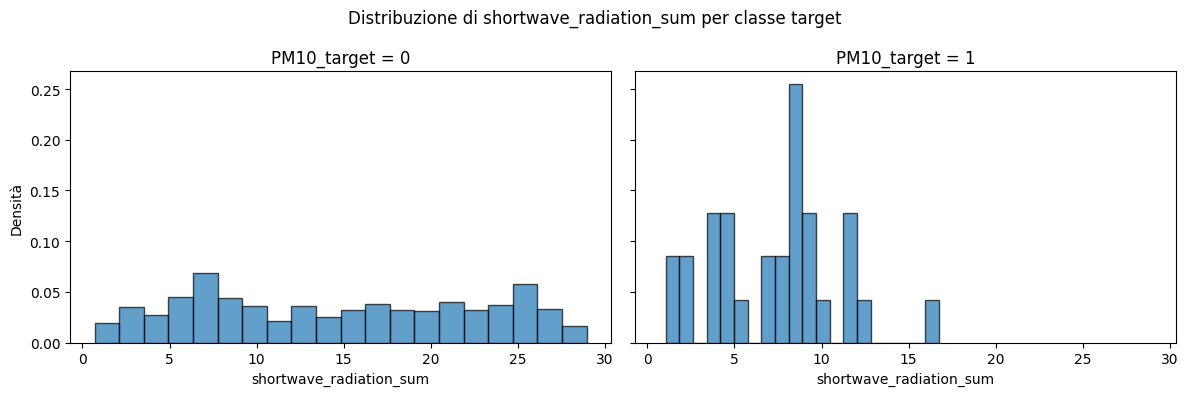

In [ ]:
x0 = df_final[df_final['PM10_target'] == 0]['shortwave_radiation_sum'].dropna()
x1 = df_final[df_final['PM10_target'] == 1]['shortwave_radiation_sum'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True, sharey=True)

axes[0].hist(x0, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[0].set_title('PM10_target = 0')
axes[0].set_xlabel('shortwave_radiation_sum')
axes[0].set_ylabel('Densità')

axes[1].hist(x1, bins=20, density=True, alpha=0.7, edgecolor='black')
axes[1].set_title('PM10_target = 1')
axes[1].set_xlabel('shortwave_radiation_sum')

plt.suptitle('Distribuzione di shortwave_radiation_sum per classe target')
plt.tight_layout()
plt.show()

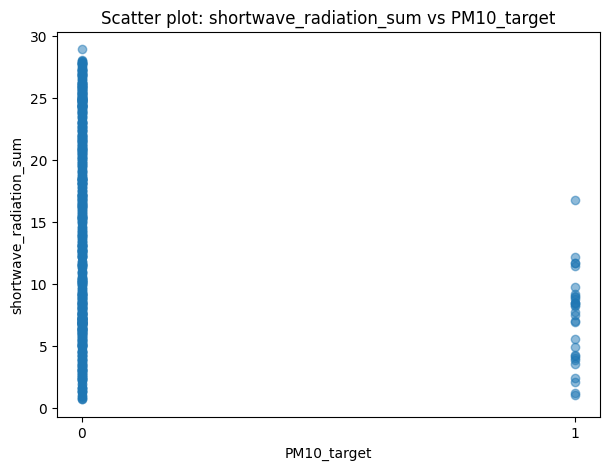

In [ ]:

plt.figure(figsize=(7, 5))

plt.scatter(
    df_final['PM10_target'],
    df_final['shortwave_radiation_sum'],
    alpha=0.5

)

plt.xlabel('PM10_target')
plt.ylabel('shortwave_radiation_sum')
plt.title('Scatter plot: shortwave_radiation_sum vs PM10_target')
plt.xticks([0, 1], ['0', '1'])

plt.show()

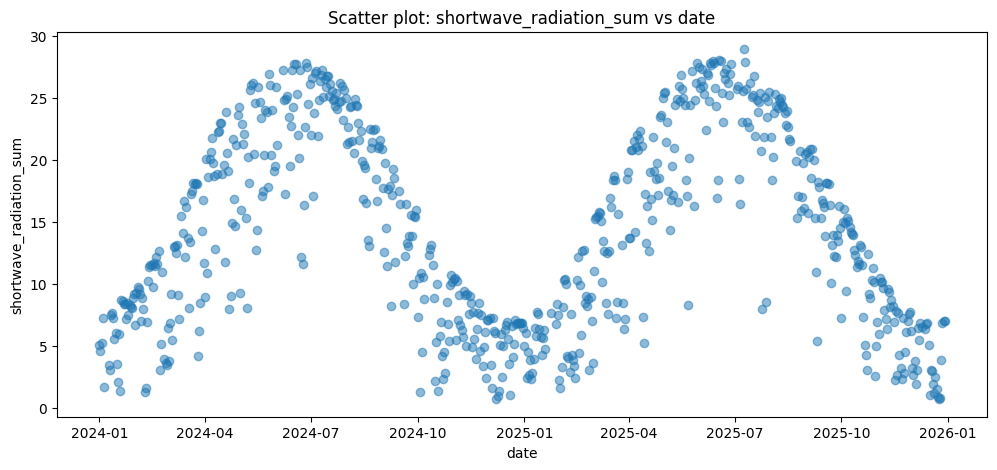

In [ ]:

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['date'],
    df_final['shortwave_radiation_sum'],
    alpha=0.5

)

plt.xlabel('date')
plt.ylabel('shortwave_radiation_sum')
plt.title('Scatter plot: shortwave_radiation_sum vs date')


plt.show()

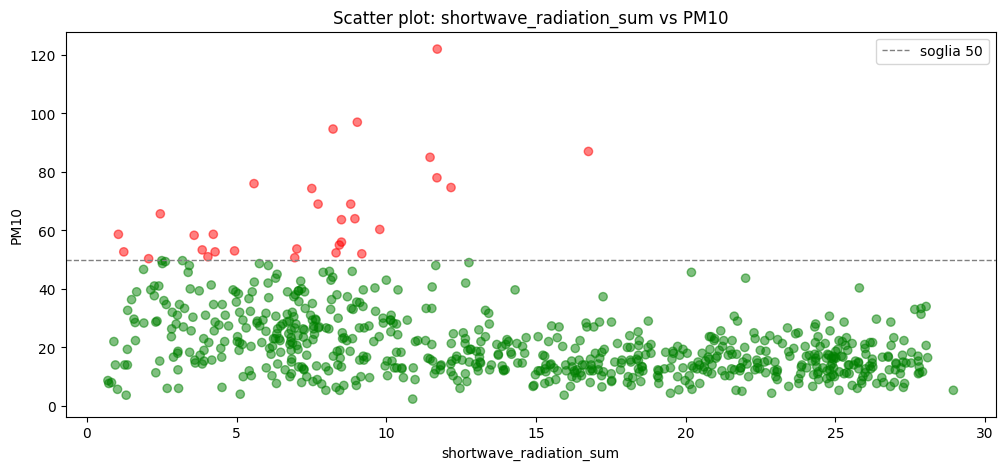

In [ ]:

colori = np.where(df_final['PM10'] > 50, 'red', 'green')

plt.figure(figsize=(12, 5))

plt.scatter(
    df_final['shortwave_radiation_sum'],
    df_final['PM10'],
    c=colori,
    alpha=0.5
)

plt.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='soglia 50')

plt.xlabel('shortwave_radiation_sum')
plt.ylabel('PM10')
plt.title('Scatter plot: shortwave_radiation_sum vs PM10')
plt.legend()

plt.show()